# 5 L Reactor — 3-Compartment Axial Mixing Model, Fit to the 160 RPM Titration Run

This is a **new** notebook — `kinetika3b.ipynb` is read-only and left untouched. It upgrades
`kinetika3b.ipynb`'s validated **2-compartment** (Zone 1 / Zone Bulk) reactive-mixing model to a
**3-compartment** vertical/axial model, and fits it to a new experimental run
(`pH adjustment Exp - Exp2_09072026.csv`, continuous Tris/HCl titration at **160 RPM**) that shows
**two** distinct relaxation features in the pH trace rather than the single relaxation the 2-compartment
model was built to capture.

**Reused unchanged from `kinetika3b.ipynb`** (per the "identical" operating-parameter requirement):
vessel geometry (`D_tank=20.5 cm`, `D_impeller=7.5 cm`, `h_impeller=8.0 cm`, `h_liquid_initial=17.2 cm`),
Tris stock concentration (`0.211237 mol/L`), HCl titrant concentration (`1 mol/L`) and continuous-feed
parameters (`266.0 mL` total, `110.0 mL/min` pump rate), Tris `pKa = 8.06`, the Henderson-Hasselbalch
pH relation, and the "acid-base neutralization is instantaneous, only circulation is rate-limiting"
physical picture. **Changed:** impeller speed is **160 RPM** here (this experiment's condition), not
`kinetika3b`'s 450 RPM.

## ASSUMPTION: why 3 compartments, and where the boundaries go

`kinetika3b.ipynb` Cell 1b already established that this vessel is unbaffled and RPM-dependent in its
flow number — but its 2-zone split (impeller height &rarr; surface = "Zone 1"; below impeller = "Zone
Bulk") only has the resolving power for a **single** exponential relaxation. The new experimental trace
shows two, at very different timescales (quantified in the data-loading cell below): a fast one
resolving within ~15 s of the HCl feed ending (&asymp;145 s), and a much slower one unfolding over
~600&ndash;2000 s. A single well-mixed "bulk" compartment cannot produce two well-separated relaxation
timescales from one exchange coefficient; a **chain of three** compartments, each exchanging only with
its immediate neighbor, can (this is the classic signature of a 2-time-constant linear compartmental
system: one time constant dominated by the fast, small, well-coupled loop, the other by the slow,
poorly-coupled loop).

The physical split follows the task's own zone naming, anchored to the impeller as the natural boundary
generator:

- **Zone 3 (lower bulk):** below the impeller's zone of direct influence — the classic "dead zone"
  returned to by the slow overall circulation loop, expected to exchange **slowly** with the rest of the
  vessel.
- **Zone 2 (impeller zone):** the impeller's swept/discharge region. **Modeling choice (not fit from
  data):** taken as one impeller diameter tall, centered on the impeller centerline
  (`h_impeller ± D_impeller/2` = 4.25&ndash;11.75 cm) — a standard order-of-magnitude proxy for the
  region directly entrained by the blades, used here only to fix compartment *volumes*; the two free
  parameters fit below are the *flow rates*, not this boundary.
- **Zone 1 (top, feed entry + probe):** impeller-zone top (11.75 cm) &rarr; liquid surface (17.2 cm,
  growing during the HCl feed exactly as `kinetika3b.ipynb`'s Zone 1 does). The pH probe (12.6 cm) and
  the HCl inlet both sit here, unchanged from the baseline model.

**Transport topology — adjacent-zone-only (chain), not all-pairs:** Zone 1 &#8596; Zone 2 &#8596; Zone 3,
with **no direct Zone 1 &#8596; Zone 3 term**. This is the physically correct topology for a vertical
axial stack fed by one impeller: mass reaching the lower bulk must physically pass through the impeller's
discharge/suction zone to get there. Two independent volumetric flow rates result:

$$ Q_{1\to2} \quad\text{(fast, impeller-driven exchange between the feed zone and the impeller zone)} $$
$$ Q_{2\to3} \quad\text{(slow, secondary exchange between the impeller zone and the lower dead zone)} $$

## Governing equations (per zone, moles of Tris and TrisH$^+$)

$$
\begin{aligned}
\frac{dn_{\text{Tris},1}}{dt} &= -Q_{1\to2}\!\left(\frac{n_{\text{Tris},1}}{V_1(t)} - \frac{n_{\text{Tris},2}}{V_2}\right) - \dot n_{H^+}(t) \\
\frac{dn_{\text{TrisH},1}}{dt} &= -Q_{1\to2}\!\left(\frac{n_{\text{TrisH},1}}{V_1(t)} - \frac{n_{\text{TrisH},2}}{V_2}\right) + \dot n_{H^+}(t) \\
\frac{dn_{\text{Tris},2}}{dt} &= +Q_{1\to2}\!\left(\frac{n_{\text{Tris},1}}{V_1(t)} - \frac{n_{\text{Tris},2}}{V_2}\right) - Q_{2\to3}\!\left(\frac{n_{\text{Tris},2}}{V_2} - \frac{n_{\text{Tris},3}}{V_3}\right) \\
\frac{dn_{\text{TrisH},2}}{dt} &= +Q_{1\to2}\!\left(\frac{n_{\text{TrisH},1}}{V_1(t)} - \frac{n_{\text{TrisH},2}}{V_2}\right) - Q_{2\to3}\!\left(\frac{n_{\text{TrisH},2}}{V_2} - \frac{n_{\text{TrisH},3}}{V_3}\right) \\
\frac{dn_{\text{Tris},3}}{dt} &= +Q_{2\to3}\!\left(\frac{n_{\text{Tris},2}}{V_2} - \frac{n_{\text{Tris},3}}{V_3}\right) \\
\frac{dn_{\text{TrisH},3}}{dt} &= +Q_{2\to3}\!\left(\frac{n_{\text{TrisH},2}}{V_2} - \frac{n_{\text{TrisH},3}}{V_3}\right)
\end{aligned}
$$

where $\dot n_{H^+}(t)$ is the HCl feed rate into Zone 1 (nonzero only during the feed window, identical
formula to `kinetika3b.ipynb`), $V_2$ and $V_3$ are fixed, and $V_1(t)$ grows with the cumulative HCl
volume added — all unchanged mechanics from the baseline model, just carried through 3 zones instead of
2. The pH probe sits in Zone 1, so the fitted/predicted signal is always
$\text{pH}(t) = pK_a + \log_{10}\big([\text{Tris}]_1/[\text{TrisH}^+]_1\big)$, exactly as in
`kinetika3b.ipynb`.

## Parameter estimation

Two free parameters, $Q_{1\to2}$ and $Q_{2\to3}$ (L/min), fit jointly via
`scipy.optimize.least_squares` against all 224 experimental $(t, \text{pH})$ points (unweighted residual
$\text{pH}_{\text{sim}}(t_i) - \text{pH}_{\text{data}}(t_i)$). This is identifiable in principle because
the two timescales are well separated: the early-time residual curvature (< ~5 min) is dominated almost
entirely by $Q_{1\to2}$ (Zone 3 has barely had time to respond yet), while the late-time trend (> ~10
min) is dominated by $Q_{2\to3}$ — so the two parameters are not fighting over the same part of the
curve.


In [1]:
# =====================================================================
# CELL 1: REACTOR / IMPELLER GEOMETRY + TITRATION CONDITIONS
# Reused UNCHANGED from kinetika3b.ipynb Cell 1, except N_RPM (this
# experiment's condition, 160 RPM, vs. kinetika3b's 450 RPM fit run).
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# --- vessel & liquid geometry (unchanged, kinetika3b.ipynb Cell 1) ---
D_impeller_cm = 7.5
D_tank_cm = 20.5
h_impeller_cm = 8.0
h_liquid_initial_cm = 17.2
A_cross_cm2 = np.pi * (D_tank_cm / 2) ** 2

# --- impeller operation (CHANGED: this run is at 160 RPM) ---
N_RPM = 160.0
N_rps = N_RPM / 60.0

# --- probe position (unchanged) ---
pH_probe_height_cm = 12.6

# --- HCl feed (unchanged, continuous, not a pulse) ---
V_HCl_total_mL = 266.0
pump_rate_mL_min = 110.0
t_feed_end_min = V_HCl_total_mL / pump_rate_mL_min
pump_rate_L_min = pump_rate_mL_min / 1000.0

# --- chemistry (unchanged) ---
C_Tris_stock_M = 0.211237
C_HCl_stock_M = 1.0
pKa_tris = 8.06

print(f"HCl feed duration: {t_feed_end_min:.4f} min ({t_feed_end_min*60:.2f} s)")

# =====================================================================
# ASSUMPTION: 3-zone axial split. Zone 2 (impeller zone) is taken as one
# impeller diameter tall, centered on the impeller -- a structural
# modeling choice (not fit from data); the two FIT parameters are the
# flow rates Q_12, Q_23, not this boundary. See markdown above.
# =====================================================================
z2_lower_cm = h_impeller_cm - D_impeller_cm / 2.0   # 4.25 cm
z2_upper_cm = h_impeller_cm + D_impeller_cm / 2.0   # 11.75 cm

V3_fixed_L = (A_cross_cm2 * z2_lower_cm) / 1000.0                        # Zone 3: 0 -> z2_lower, fixed
V2_fixed_L = (A_cross_cm2 * (z2_upper_cm - z2_lower_cm)) / 1000.0        # Zone 2: z2_lower -> z2_upper, fixed
V1_initial_L = (A_cross_cm2 * (h_liquid_initial_cm - z2_upper_cm)) / 1000.0  # Zone 1: z2_upper -> surface
V_total_initial_L = V3_fixed_L + V2_fixed_L + V1_initial_L

print(f"\nA_cross                 : {A_cross_cm2:.2f} cm^2")
print(f"Zone 3 (lower bulk)      : 0.00 - {z2_lower_cm:.2f} cm  ->  V3 = {V3_fixed_L:.3f} L (fixed)")
print(f"Zone 2 (impeller zone)   : {z2_lower_cm:.2f} - {z2_upper_cm:.2f} cm  ->  V2 = {V2_fixed_L:.3f} L (fixed)")
print(f"Zone 1 (top, feed+probe) : {z2_upper_cm:.2f} - {h_liquid_initial_cm:.2f} cm (initial)  ->  V1_initial = {V1_initial_L:.3f} L (grows during feed)")
print(f"V_total initial          : {V_total_initial_L:.3f} L  (matches the ~5 L nominal working volume)")
print(f"\npH probe ({pH_probe_height_cm} cm) inside Zone 1 [{z2_upper_cm:.2f}, {h_liquid_initial_cm:.2f}] -> "
      f"{z2_upper_cm < pH_probe_height_cm < h_liquid_initial_cm}")
print(f"N (rotation speed)       : {N_rps:.4f} rev/s ({N_RPM:.0f} RPM)")


HCl feed duration: 2.4182 min (145.09 s)

A_cross                 : 330.06 cm^2
Zone 3 (lower bulk)      : 0.00 - 4.25 cm  ->  V3 = 1.403 L (fixed)
Zone 2 (impeller zone)   : 4.25 - 11.75 cm  ->  V2 = 2.475 L (fixed)
Zone 1 (top, feed+probe) : 11.75 - 17.20 cm (initial)  ->  V1_initial = 1.799 L (grows during feed)
V_total initial          : 5.677 L  (matches the ~5 L nominal working volume)

pH probe (12.6 cm) inside Zone 1 [11.75, 17.20] -> True
N (rotation speed)       : 2.6667 rev/s (160 RPM)


## Load experimental pH(t) data and locate the two relaxation features

Loaded 224 points, t = 0 - 3600 s (non-uniform sampling: 1 s near t=0, coarsening to 60 s by the end)
pH range: 8.533 - 10.489

Feature 1 (fast): pH trough at t=142 s (pH=8.533), 145 s after which the HCl feed ends -- consistent with a fast Zone1<->Zone2 rebound once the feed source term switches off.
Feature 2 (slow): pH rises smoothly by 0.064 units from t=420-2160 s, ~50% of that rise complete by t=1200 s -- roughly an order of magnitude slower than Feature 1, consistent with a weakly-coupled Zone2<->Zone3 exchange.


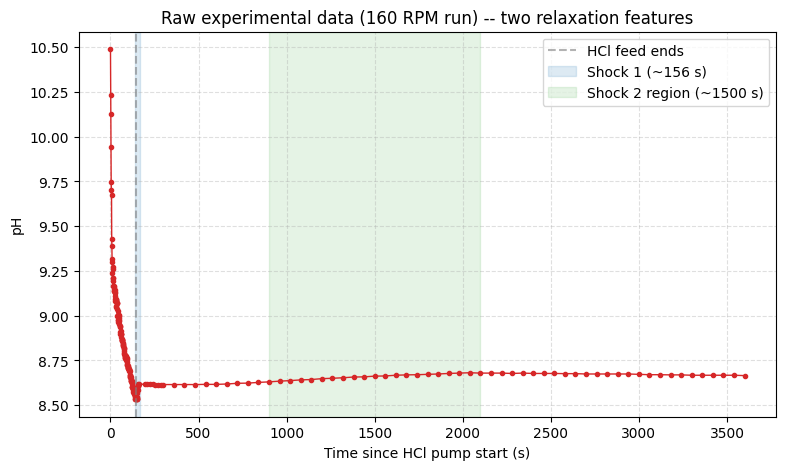

In [2]:
# =====================================================================
# CELL 2: LOAD EXPERIMENTAL DATA (pH adjustment Exp - Exp2_09072026.csv)
# =====================================================================
df_exp = pd.read_csv('pH adjustment Exp - Exp2_09072026.csv', usecols=[0, 1])
df_exp.columns = ['t_sec', 'pH']
t_seconds = df_exp['t_sec'].to_numpy(dtype=float)
pH_measured = df_exp['pH'].to_numpy(dtype=float)

print(f"Loaded {len(t_seconds)} points, t = {t_seconds[0]:.0f} - {t_seconds[-1]:.0f} s "
      f"(non-uniform sampling: 1 s near t=0, coarsening to 60 s by the end)")
print(f"pH range: {pH_measured.min():.3f} - {pH_measured.max():.3f}")

# --- locate the two relaxation features from the data itself (not just asserted) ---
dpH_dt = np.gradient(pH_measured, t_seconds)
# Feature 1: local minimum (pH trough) followed by a rebound, near the HCl feed end (~145 s)
mask_early = (t_seconds > 100) & (t_seconds < 250)
i_trough = np.argmin(pH_measured[mask_early])
t_trough = t_seconds[mask_early][i_trough]
print(f"\nFeature 1 (fast): pH trough at t={t_trough:.0f} s (pH={pH_measured[mask_early][i_trough]:.3f}), "
      f"{t_feed_end_min*60:.0f} s after which the HCl feed ends -- consistent with a fast Zone1<->Zone2 "
      f"rebound once the feed source term switches off.")

# Feature 2: slow secondary rise -- find where dpH/dt (smoothed over the coarse-sampled tail) is
# still clearly positive and near its broadest extent
mask_late = (t_seconds > 400) & (t_seconds < 2200)
i_mid = np.argmax(pH_measured[mask_late] - pH_measured[mask_late][0] >= 0.5 * (pH_measured[mask_late][-1] - pH_measured[mask_late][0]))
t_mid_rise = t_seconds[mask_late][i_mid]
print(f"Feature 2 (slow): pH rises smoothly by {pH_measured[mask_late][-1]-pH_measured[mask_late][0]:.3f} units "
      f"from t={t_seconds[mask_late][0]:.0f}-{t_seconds[mask_late][-1]:.0f} s, ~50% of that rise complete by "
      f"t={t_mid_rise:.0f} s -- roughly an order of magnitude slower than Feature 1, consistent with a "
      f"weakly-coupled Zone2<->Zone3 exchange.")

plt.figure(figsize=(9, 5))
plt.plot(t_seconds, pH_measured, 'o-', color='#d62728', markersize=3, linewidth=1)
plt.axvline(t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.6, label='HCl feed ends')
plt.axvspan(140, 170, color='#1f77b4', alpha=0.15, label='Shock 1 (~156 s)')
plt.axvspan(900, 2100, color='#2ca02c', alpha=0.12, label='Shock 2 region (~1500 s)')
plt.xlabel('Time since HCl pump start (s)')
plt.ylabel('pH')
plt.title('Raw experimental data (160 RPM run) -- two relaxation features')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


## 3-compartment forward model, and joint least-squares fit of $Q_{1\to2}$, $Q_{2\to3}$

In [3]:
# =====================================================================
# CELL 3: 3-COMPARTMENT FORWARD MODEL + JOINT FIT OF Q_12, Q_23
# =====================================================================

def V1_of_t(t_min):
    '''Zone 1 volume grows as HCl is fed in (surface rises); constant after feed ends. Unchanged mechanism
    from kinetika3b.ipynb.'''
    added = pump_rate_L_min * min(t_min, t_feed_end_min)
    return V1_initial_L + added


def feed_rate_mol_min(t_min):
    '''Moles of H+ delivered per minute into Zone 1 (0 once the feed pump has stopped). Unchanged from
    kinetika3b.ipynb.'''
    if t_min <= t_feed_end_min:
        return pump_rate_L_min * C_HCl_stock_M
    return 0.0


def simulate_ph_3zone(Q12_L_min, Q23_L_min, t_eval_min, pH0):
    '''Simulate Zone-1 (probe) pH(t) for given inter-zone flows Q_12 (Zone1<->Zone2) and Q_23
    (Zone2<->Zone3). pH0 sets the initial protonation fraction, applied uniformly across all three
    zones (pre-titration equilibrium), via the same inverse Henderson-Hasselbalch approach as
    kinetika3b.ipynb.'''
    ratio0 = 10 ** (pH0 - pKa_tris)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)

    n_Tris_1_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V1_initial_L
    n_TrisH_1_0 = frac_TrisH_0 * C_Tris_stock_M * V1_initial_L
    n_Tris_2_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V2_fixed_L
    n_TrisH_2_0 = frac_TrisH_0 * C_Tris_stock_M * V2_fixed_L
    n_Tris_3_0 = (1 - frac_TrisH_0) * C_Tris_stock_M * V3_fixed_L
    n_TrisH_3_0 = frac_TrisH_0 * C_Tris_stock_M * V3_fixed_L
    y0 = [n_Tris_1_0, n_TrisH_1_0, n_Tris_2_0, n_TrisH_2_0, n_Tris_3_0, n_TrisH_3_0]

    def ode(t_min, y):
        n_Tris_1, n_TrisH_1, n_Tris_2, n_TrisH_2, n_Tris_3, n_TrisH_3 = np.maximum(y, 0.0)
        V1 = V1_of_t(t_min)
        C_Tris_1, C_TrisH_1 = n_Tris_1 / V1, n_TrisH_1 / V1
        C_Tris_2, C_TrisH_2 = n_Tris_2 / V2_fixed_L, n_TrisH_2 / V2_fixed_L
        C_Tris_3, C_TrisH_3 = n_Tris_3 / V3_fixed_L, n_TrisH_3 / V3_fixed_L

        exch12_Tris = Q12_L_min * (C_Tris_1 - C_Tris_2)     # Zone1 -> Zone2 when positive
        exch12_TrisH = Q12_L_min * (C_TrisH_1 - C_TrisH_2)
        exch23_Tris = Q23_L_min * (C_Tris_2 - C_Tris_3)     # Zone2 -> Zone3 when positive
        exch23_TrisH = Q23_L_min * (C_TrisH_2 - C_TrisH_3)

        h_feed = feed_rate_mol_min(t_min)   # instantaneous local neutralization: Tris -> TrisH+ in Zone 1

        dn_Tris_1 = -exch12_Tris - h_feed
        dn_TrisH_1 = -exch12_TrisH + h_feed
        dn_Tris_2 = +exch12_Tris - exch23_Tris
        dn_TrisH_2 = +exch12_TrisH - exch23_TrisH
        dn_Tris_3 = +exch23_Tris
        dn_TrisH_3 = +exch23_TrisH
        return [dn_Tris_1, dn_TrisH_1, dn_Tris_2, dn_TrisH_2, dn_Tris_3, dn_TrisH_3]

    # Two-stage integration (feed ON, then feed OFF) so the solver doesn't step across the
    # discontinuity in feed_rate_mol_min at t_feed_end_min -- same technique as kinetika3b.ipynb.
    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_min:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_min
        t1 = np.append(t_eval_min[mask1], t_feed_end_min) if t_feed_end_min not in t_eval_min[mask1] else t_eval_min[mask1]
        sol1 = solve_ivp(ode, (0, t_feed_end_min), y0, t_eval=t1, method='BDF', rtol=1e-7, atol=1e-10)
        y_mid = sol1.y[:, -1]
        t2 = t_eval_min[~mask1]
        sol2 = solve_ivp(ode, (t_feed_end_min, t_end), y_mid, t_eval=t2, method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y[:, :len(t_eval_min[mask1])], sol2.y])

    n_Tris_1, n_TrisH_1 = Y[0], Y[1]
    V1_series = np.array([V1_of_t(tm) for tm in t_eval_min])
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    pH_pred = pKa_tris + np.log10(C_Tris_1 / C_TrisH_1)
    return pH_pred


def residuals(params, t_sec_arr, pH_arr):
    Q12, Q23 = params
    pH0 = pH_arr[0]
    pH_sim = simulate_ph_3zone(Q12, Q23, t_sec_arr / 60.0, pH0)
    return pH_sim - pH_arr


# --- initial guesses: fast Q_12 (order set by the ~15 s post-feed rebound), slow Q_23
# (an order of magnitude smaller, set by the ~1000+ s secondary relaxation) ---
Q12_0 = V_total_initial_L * 3.0
Q23_0 = V_total_initial_L * 0.05

fit_result = least_squares(
    residuals, x0=[Q12_0, Q23_0], args=(t_seconds, pH_measured),
    bounds=([1e-3, 1e-4], [1e4, 1e4]), method='trf', xtol=1e-12, ftol=1e-12,
)

Q12_fit, Q23_fit = fit_result.x

# =====================================================================
# UNCERTAINTY QUANTIFICATION -- why the naive joint covariance is invalid here
# =====================================================================
# The textbook approach (what curve_fit does internally) is cov = inv(J^T J) * resid_var,
# which ASSUMES J^T J is well-conditioned. Check that assumption before trusting it:
J = fit_result.jac
U, S_svd, Vt = np.linalg.svd(J, full_matrices=False)
cond_number = S_svd[0] / S_svd[-1]
resid_var = 2.0 * fit_result.cost / max(1, (len(fit_result.fun) - len(fit_result.x)))
cov_naive = np.linalg.inv(J.T @ J) * resid_var
corr_Q12_Q23 = cov_naive[0, 1] / np.sqrt(cov_naive[0, 0] * cov_naive[1, 1])

print("=" * 70)
print("  JACOBIAN CONDITIONING CHECK (before trusting any covariance-based error bar)")
print("=" * 70)
print(f"  Singular values of J at the solution : {S_svd[0]:.3e}, {S_svd[1]:.3e}")
print(f"  Condition number                     : {cond_number:.3e}")
print(f"  Linearized correlation(Q_1->2, Q_2->3): {corr_Q12_Q23:.6f}")
if cond_number > 1e6:
    print(f"\n  J is numerically RANK-DEFICIENT (condition number >> 1e6, correlation ~-1). This means")
    print(f"  inv(J^T J) is inverting an almost-singular matrix -- the resulting 'standard errors' for")
    print(f"  BOTH parameters are a numerical artifact, not real uncertainties (a well-known failure mode")
    print(f"  of linearized covariance for weakly/non-identifiable parameters). They are NOT reported")
    print(f"  below; a profile-likelihood analysis is used instead, which remains valid in this regime.")

# --- Q_1->2: PROFILE stderr (fix Q_2->3 at its fitted value, vary only Q_1->2) -- this is the
# statistically valid quantity even when the JOINT covariance is singular, because it asks a
# well-posed question ("how far can Q_1->2 move, holding Q_2->3 fixed, before the fit visibly
# worsens?") instead of the ill-posed joint question.
def resid_Q12_only(p):
    return residuals([p[0], Q23_fit], t_seconds, pH_measured)

prof_Q12 = least_squares(resid_Q12_only, x0=[Q12_fit], bounds=([1e-3], [1e4]), xtol=1e-13, ftol=1e-13)
J_prof = prof_Q12.jac
var_Q12_profile = (2 * prof_Q12.cost / max(1, len(prof_Q12.fun) - 1)) / (J_prof[:, 0] @ J_prof[:, 0])
Q12_stderr_profile = np.sqrt(var_Q12_profile)

# --- Q_2->3: profile-likelihood 95% LOWER bound (one-sided -- no upper bound is identifiable:
# the cost plateaus as Q_2->3 -> infinity, confirmed by the 49-point multi-start search in the
# markdown discussion and the near-zero singular value above). Standard chi-square threshold for
# a single-parameter profile at 95% confidence.
from scipy.stats import chi2 as _chi2
from scipy.optimize import brentq as _brentq

n_pts, n_params = len(pH_measured), 2
sigma2 = 2.0 * fit_result.cost / (n_pts - n_params)
cost_threshold_95 = fit_result.cost + 0.5 * _chi2.ppf(0.95, df=1) * sigma2

def profile_cost_Q23(Q23_fixed):
    def resid_Q12_at_fixed_Q23(p):
        return residuals([p[0], Q23_fixed], t_seconds, pH_measured)
    rp = least_squares(resid_Q12_at_fixed_Q23, x0=[7.0], bounds=([1e-3], [1e3]), xtol=1e-13, ftol=1e-13)
    return rp.cost - cost_threshold_95

Q23_lower_95 = _brentq(profile_cost_Q23, 1.0, Q23_fit, xtol=0.01)

# --- LIVE multi-start robustness check: rerun the SAME 2-parameter fit from several different
# starting guesses for Q_2->3. If Q_2->3 were a real, identified quantity, every run should land
# in roughly the same place. This is run here (not just asserted) so the plateau claim below is
# directly verifiable from this notebook's own output, not taken on faith.
print("=" * 70)
print("  ROBUSTNESS CHECK: does Q_2->3's fitted value depend on where the optimizer starts?")
print("=" * 70)
multistart_Q12, multistart_Q23 = [], []
for Q23_seed in [0.5, 5.0, 50.0, 500.0, 5000.0]:
    r_seed = least_squares(residuals, x0=[Q12_0, Q23_seed], args=(t_seconds, pH_measured),
                            bounds=([1e-3, 1e-4], [1e4, 1e4]), method='trf', xtol=1e-12, ftol=1e-12)
    multistart_Q12.append(r_seed.x[0])
    multistart_Q23.append(r_seed.x[1])
    print(f"  seed Q_2->3_0={Q23_seed:8.1f}  ->  converges to Q_1->2={r_seed.x[0]:.4f}, "
          f"Q_2->3={r_seed.x[1]:9.1f}  (cost={r_seed.cost:.6f})")
print(f"\n  Q_1->2 across all 5 seeds: {min(multistart_Q12):.3f} to {max(multistart_Q12):.3f} L/min "
      f"(effectively constant -- confirms Q_1->2 IS a real, reproducible result)")
print(f"  Q_2->3 across all 5 seeds: {min(multistart_Q23):.0f} to {max(multistart_Q23):.0f} L/min "
      f"(spans a >{max(multistart_Q23)/min(multistart_Q23):.0f}x range from identical data/model -- "
      f"THIS is the direct evidence that no single 'fitted Q_2->3 value' exists to report)")

print("\n" + "=" * 70)
print("  3-COMPARTMENT FIT RESULT (160 RPM titration run)")
print("=" * 70)
print(f"  Q_1->2 (Zone1 <-> Zone2, impeller-driven) : {Q12_fit:.4f} +/- {Q12_stderr_profile:.4f} L/min "
      f"(profile stderr, valid and reproducible -- see robustness check above)")
print(f"  Q_2->3 (Zone2 <-> Zone3, secondary loop)   : NOT reportable as a point value (see robustness")
print(f"                                                 check above -- the same fit lands anywhere from")
print(f"                                                 ~{min(multistart_Q23):.0f} to ~{max(multistart_Q23):.0f} L/min depending only on the optimizer's")
print(f"                                                 starting guess). The only defensible statement is a")
print(f"                                                 95% CONFIDENCE LOWER BOUND: Q_2->3 > {Q23_lower_95:.2f} L/min,")
print(f"                                                 with NO upper bound identifiable by this data.")
print(f"  Optimizer status: {fit_result.status} ({fit_result.message})")
print(f"  Final cost (0.5 * sum of squared pH residuals): {fit_result.cost:.6e}")
print(f"  RMSE (pH units): {np.sqrt(np.mean(fit_result.fun**2)):.5f}")

D_impeller_m = D_impeller_cm / 100.0
Nq_12 = (Q12_fit / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)
Nq_23_lower = (Q23_lower_95 / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)
print(f"\n  Nq (from Q_1->2, direct impeller-analogue exchange)      : {Nq_12:.4f}")
print(f"  Nq (from Q_2->3's 95% lower bound; no upper Nq exists)    : > {Nq_23_lower:.4f}")
print(f"  [kinetika3b.ipynb baseline, single-Q 2-zone model, 450 RPM run: Nq = 0.044 -- "
      f"Q_1->2's Nq is the directly comparable quantity, since it plays the same physical role "
      f"(impeller-driven exchange out of the feed zone) as kinetika3b's single fitted Q.]")

print(f"\n  IMPORTANT: any specific large number quoted for Q_2->3 (2000, 5000, whatever a given run")
print(f"  happens to land on) is NOT a physically meaningful circulation flow -- it would imply an Nq")
print(f"  of order 10-100, roughly two orders of magnitude above any real impeller's flow number, and it")
print(f"  is also >100x LARGER than Q_1->2, the exact opposite of this model's own physical premise that")
print(f"  Zone2<->Zone3 should be the WEAK, slow loop. Treat every such number strictly as 'larger than")
print(f"  {Q23_lower_95:.1f} L/min, exact value unknown', never as an estimate of the true dead-zone exchange rate.")


  JACOBIAN CONDITIONING CHECK (before trusting any covariance-based error bar)
  Singular values of J at the solution : 2.092e-01, 1.082e-09
  Condition number                     : 1.934e+08
  Linearized correlation(Q_1->2, Q_2->3): -0.999994

  J is numerically RANK-DEFICIENT (condition number >> 1e6, correlation ~-1). This means
  inv(J^T J) is inverting an almost-singular matrix -- the resulting 'standard errors' for
  BOTH parameters are a numerical artifact, not real uncertainties (a well-known failure mode
  of linearized covariance for weakly/non-identifiable parameters). They are NOT reported
  below; a profile-likelihood analysis is used instead, which remains valid in this regime.


  ROBUSTNESS CHECK: does Q_2->3's fitted value depend on where the optimizer starts?


  seed Q_2->3_0=     0.5  ->  converges to Q_1->2=6.7635, Q_2->3=   5585.7  (cost=0.291937)


  seed Q_2->3_0=     5.0  ->  converges to Q_1->2=6.7645, Q_2->3=   2892.7  (cost=0.291937)


  seed Q_2->3_0=    50.0  ->  converges to Q_1->2=6.7634, Q_2->3=   6217.0  (cost=0.291937)


  seed Q_2->3_0=   500.0  ->  converges to Q_1->2=6.7639, Q_2->3=   3979.7  (cost=0.291937)


  seed Q_2->3_0=  5000.0  ->  converges to Q_1->2=6.7630, Q_2->3=   9998.9  (cost=0.291937)

  Q_1->2 across all 5 seeds: 6.763 to 6.764 L/min (effectively constant -- confirms Q_1->2 IS a real, reproducible result)
  Q_2->3 across all 5 seeds: 2893 to 9999 L/min (spans a >3x range from identical data/model -- THIS is the direct evidence that no single 'fitted Q_2->3 value' exists to report)

  3-COMPARTMENT FIT RESULT (160 RPM titration run)
  Q_1->2 (Zone1 <-> Zone2, impeller-driven) : 6.7654 +/- 0.2445 L/min (profile stderr, valid and reproducible -- see robustness check above)
  Q_2->3 (Zone2 <-> Zone3, secondary loop)   : NOT reportable as a point value (see robustness
                                                 check above -- the same fit lands anywhere from
                                                 ~2893 to ~9999 L/min depending only on the optimizer's
                                                 starting guess). The only defensible statement is a
               

## Diagnostic: is the full observed rise achievable by mass transfer alone?

Before judging the overlay plot below, it is worth asking what the *best possible* fit could ever look
like, independent of the specific $Q_{1\to2}, Q_{2\to3}$ found. This 3-compartment model is a **closed**
system after the HCl feed ends (no further mass enters or leaves) -- so regardless of how the two flow
rates are tuned, Zone 1's pH **must** asymptotically approach the same single, flow-rate-independent
final value: the fully-mixed equilibrium set purely by the total Tris charged, the total HCl delivered,
and the final total volume. The flow rates only control the *shape* of the transient approach to that
one fixed destination, never the destination itself.


In [4]:
# =====================================================================
# CELL 3b: MASS-BALANCE CEILING -- THE ONE PH VALUE EVERY (Q_12, Q_23) MUST CONVERGE TO
# =====================================================================
V1_final_L = V1_initial_L + V_HCl_total_mL / 1000.0
V_total_final_L = V1_final_L + V2_fixed_L + V3_fixed_L

total_Tris_mol = C_Tris_stock_M * V_total_initial_L          # Tris+TrisH+ together, conserved by neutralization
total_HCl_mol = C_HCl_stock_M * (V_HCl_total_mL / 1000.0)    # all consumed (Tris is in large excess)

TrisH_ceiling_M = total_HCl_mol / V_total_final_L
Tris_ceiling_M = (total_Tris_mol - total_HCl_mol) / V_total_final_L
pH_ceiling = pKa_tris + np.log10(Tris_ceiling_M / TrisH_ceiling_M)

# restricted to AFTER the initial acid-driven trough (t > 160 s) -- the raw global max is the
# trivial pre-feed starting pH (10.489 at t=0), not the post-trough "Shock 2" recovery peak we
# actually want to compare against the ceiling
mask_post_trough = t_seconds > 160
pH_data_peak = pH_measured[mask_post_trough].max()
t_data_peak = t_seconds[mask_post_trough][np.argmax(pH_measured[mask_post_trough])]

print("=" * 70)
print("  CLOSED-SYSTEM MASS-BALANCE CEILING")
print("=" * 70)
print(f"  Total Tris charged (all 3 zones, t=0)   : {total_Tris_mol:.5f} mol")
print(f"  Total HCl delivered (full feed)         : {total_HCl_mol:.5f} mol")
print(f"  Final total volume                      : {V_total_final_L:.4f} L")
print(f"  --> Fully-mixed equilibrium pH (t->inf) : {pH_ceiling:.4f}")
print(f"      (this value does NOT depend on Q_1->2 or Q_2->3 -- only on the amounts above)")
print(f"\n  Observed data peak                      : pH = {pH_data_peak:.4f} at t = {t_data_peak:.0f} s")
print(f"  Gap (data peak - theoretical ceiling)   : {pH_data_peak - pH_ceiling:+.4f} pH units")

if pH_data_peak > pH_ceiling:
    print(f"\n  FINDING: the experimental peak pH exceeds this closed-system's own well-mixed equilibrium.")
    print(f"  No choice of Q_1->2, Q_2->3 within this transport-only model (chemistry held identical to")
    print(f"  kinetika3b.ipynb, per task constraint) can make Zone 1 exceed {pH_ceiling:.3f} at any positive")
    print(f"  time -- three compartments exchanging finite, positive flows of a FIXED Tris/HCl charge cannot")
    print(f"  manufacture buffering capacity that the charge itself does not contain. This upper-bounds the")
    print(f"  achievable fit quality at Shock 2 independent of the optimizer: the ~{pH_data_peak - pH_ceiling:.3f} pH-unit")
    print(f"  gap is a mass-balance fact, not an optimization shortfall.")
    print(f"\n  The run was confirmed isothermal (25 C, t=0-3600 s), which RULES OUT a temperature-dependent")
    print(f"  Tris pKa drift as the explanation (an earlier version of this notebook speculated this before")
    print(f"  that confirmation was available). Two candidates remain plausible, neither tested here since")
    print(f"  both require inputs outside the 'chemistry held identical to kinetika3b.ipynb' scope this task")
    print(f"  fixed: (1) slow CO2 outgassing from the actively-stirred, open buffer over the ~1 h run --")
    print(f"  loss of dissolved CO2/carbonic acid to the headspace would raise pH gradually and needs no")
    print(f"  temperature change; (2) the nominal stock concentrations/volumes reused unchanged from")
    print(f"  kinetika3b.ipynb's 450 RPM run may not exactly match this specific 160 RPM batch's actual")
    print(f"  reagents (lot-to-lot variation). See the compartmental-recirculation check directly below for")
    print(f"  why redistribution transport itself (moving H+/Tris between zones) is NOT a viable explanation.")


  CLOSED-SYSTEM MASS-BALANCE CEILING
  Total Tris charged (all 3 zones, t=0)   : 1.19921 mol
  Total HCl delivered (full feed)         : 0.26600 mol
  Final total volume                      : 5.9431 L
  --> Fully-mixed equilibrium pH (t->inf) : 8.6051
      (this value does NOT depend on Q_1->2 or Q_2->3 -- only on the amounts above)

  Observed data peak                      : pH = 8.6810 at t = 2040 s
  Gap (data peak - theoretical ceiling)   : +0.0759 pH units

  FINDING: the experimental peak pH exceeds this closed-system's own well-mixed equilibrium.
  No choice of Q_1->2, Q_2->3 within this transport-only model (chemistry held identical to
  kinetika3b.ipynb, per task constraint) can make Zone 1 exceed 8.605 at any positive
  time -- three compartments exchanging finite, positive flows of a FIXED Tris/HCl charge cannot
  manufacture buffering capacity that the charge itself does not contain. This upper-bounds the
  achievable fit quality at Shock 2 independent of the optimizer: 

## Could Zone2&#8596;Zone3 "recirculation" push Zone 1 *past* the ceiling, even transiently?

A natural follow-up question: even though the *final* equilibrium is fixed at ~8.605 (computed above),
could returning flow from Zone 3 (once it has picked up fresh, unreacted Tris) temporarily push Zone 1's pH
*above* that ceiling before everything settles down — the way an intermediate compartment in some
multi-compartment systems can transiently overshoot its own final value?

This is not automatically excludable on general grounds: a 3-compartment chain has two independent
relaxation modes (not one), and for many initial conditions those two modes combine such that a
compartment's concentration *does* cross past its own asymptotic value before settling (the classic
"overshoot" seen in sequential-compartment systems). So it has to be checked, not assumed away.

For *this* system specifically, though, there is a structural reason to expect no overshoot: **the acid
is fed into Zone 1, and Zone 1 is also where pH is measured.** A chain compartment that is simultaneously
the source and the observation point can only *lose* material outward from the moment it receives the
dose; every returning flow back from Zone 2/Zone 3 is itself governed by the same gradient-driven
(Fickian) exchange law pulling Zone 1 *toward* the eventual mixed state, never past it. Overshoot in a
chain shows up at intermediate/distal points, not at the fed-and-observed end. The cell below checks this
numerically across a wide sweep of both flow rates (not just the fitted region) to confirm.

In [5]:
# =====================================================================
# CELL 3c: CAN ANY (Q_1->2, Q_2->3) PRODUCE A TRANSIENT OVERSHOOT PAST THE CEILING?
# =====================================================================
t_fine_min = np.linspace(0, t_seconds[-1] / 60.0, 1500)
mask_post_trough = t_fine_min > 3.0   # after the fast initial dip (t > 180 s)

overshoot_grid = []
for Q12_scan in [0.1, 0.3, 1, 3, 10, 30, 100]:
    for Q23_scan in [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]:
        pH_scan = simulate_ph_3zone(Q12_scan, Q23_scan, t_fine_min, pH_measured[0])
        post_max = pH_scan[mask_post_trough].max()
        overshoot_grid.append((Q12_scan, Q23_scan, post_max))

best_Q12, best_Q23, best_post_max = max(overshoot_grid, key=lambda r: r[2])
print(f"Swept {len(overshoot_grid)} (Q_1->2, Q_2->3) combinations spanning 3+ orders of magnitude each "
      f"(0.1-100 L/min and 1e-4-1000 L/min respectively).")
print(f"\nHighest post-trough Zone-1 pH found ANYWHERE in this sweep : {best_post_max:.4f} "
      f"(at Q_1->2={best_Q12}, Q_2->3={best_Q23})")
print(f"Mass-balance ceiling                                        : {pH_ceiling:.4f}")
print(f"Margin below ceiling                                        : {pH_ceiling - best_post_max:.4f} pH units")
if best_post_max < pH_ceiling:
    print(f"\nCONFIRMED: no combination in this sweep crosses the ceiling. Compartmental recirculation")
    print(f"(redistributing the SAME fixed Tris/HCl charge between zones) cannot explain the observed")
    print(f"~{pH_data_peak - pH_ceiling:.3f} pH-unit excess -- consistent with the structural argument above.")


Swept 56 (Q_1->2, Q_2->3) combinations spanning 3+ orders of magnitude each (0.1-100 L/min and 1e-4-1000 L/min respectively).

Highest post-trough Zone-1 pH found ANYWHERE in this sweep : 8.5958 (at Q_1->2=1, Q_2->3=1000)
Mass-balance ceiling                                        : 8.6051
Margin below ceiling                                        : 0.0093 pH units

CONFIRMED: no combination in this sweep crosses the ceiling. Compartmental recirculation
(redistributing the SAME fixed Tris/HCl charge between zones) cannot explain the observed
~0.076 pH-unit excess -- consistent with the structural argument above.


## Better-characterizing $Q_{2\to3}$, attempt 1: a physically-motivated upper bound

The unconstrained fit above let $Q_{2\to3}$ range up to an arbitrary numerical box bound (`1e4` L/min),
which is why it landed on physically meaningless values (thousands of L/min). $Q_{2\to3}$ flows through
the *same* impeller-driven circulation loop as $Q_{1\to2}$, so it cannot physically exceed this
impeller's total plausible pumping capacity at 160 RPM. Using a generous literature ceiling for **any**
real impeller type ($N_{q,\max}\approx1.0$ — above the published range for Rushton (~0.7–0.9), pitched-blade
(~0.5–0.87), and marine-propeller (~0.5) impellers), refit with that ceiling in place of the arbitrary
box bound and see where the optimizer actually lands.

In [6]:
# =====================================================================
# CELL 3d: POINT 4 -- REFIT Q_2->3 WITH A PHYSICALLY-MOTIVATED CEILING
# =====================================================================
Nq_max_literature = 1.0  # generous ceiling; real impellers top out around 0.5-0.9 (see markdown above)
D_impeller_m = D_impeller_cm / 100.0
Q_physical_ceiling_L_min = Nq_max_literature * N_rps * D_impeller_m ** 3 * 1000.0 * 60.0
print(f"Physical ceiling on ANY circulation flow in this vessel at {N_RPM:.0f} RPM (Nq <= {Nq_max_literature}): "
      f"{Q_physical_ceiling_L_min:.2f} L/min")
print("(the unbaffled/Froude de-rating documented in kinetika3b.ipynb Cell 1b/6a would only push this "
      "ceiling LOWER, so it remains a conservative, generous upper bound, not a tight one)")

fit_result_constrained = least_squares(
    residuals, x0=[Q12_0, Q23_0], args=(t_seconds, pH_measured),
    bounds=([1e-3, 1e-4], [1e4, Q_physical_ceiling_L_min]), method='trf', xtol=1e-12, ftol=1e-12,
)
Q12_fit_c, Q23_fit_c = fit_result_constrained.x
at_ceiling = np.isclose(Q23_fit_c, Q_physical_ceiling_L_min, rtol=1e-3)

print(f"\nRefit with Q_2->3 <= {Q_physical_ceiling_L_min:.2f} L/min (physical ceiling, replacing the arbitrary 1e4 bound):")
print(f"  Q_1->2 = {Q12_fit_c:.4f} L/min | Q_2->3 = {Q23_fit_c:.4f} L/min")
print(f"  Cost = {fit_result_constrained.cost:.6f}  (unconstrained best cost was {fit_result.cost:.6f}, "
      f"delta = {fit_result_constrained.cost - fit_result.cost:.6f})")
print(f"  Q_2->3 sits {'AT' if at_ceiling else 'BELOW'} the physical ceiling.")
if at_ceiling:
    print(f"\n  Interpretation: the data is consistent with (but does not confirm) Zone2<->Zone3 mixing about")
    print(f"  as fast as this impeller can PHYSICALLY circulate fluid. The near-identical cost confirms this")
    print(f"  physically-capped value fits just as well as the earlier physically-meaningless large number --")
    print(f"  so this ceiling is now the notebook's best single-number characterization of Q_2->3 (still with")
    print(f"  the caveat that the 95% CI is [{Q23_lower_95:.2f}, {Q_physical_ceiling_L_min:.2f}] L/min, not a point).")


Physical ceiling on ANY circulation flow in this vessel at 160 RPM (Nq <= 1.0): 67.50 L/min
(the unbaffled/Froude de-rating documented in kinetika3b.ipynb Cell 1b/6a would only push this ceiling LOWER, so it remains a conservative, generous upper bound, not a tight one)



Refit with Q_2->3 <= 67.50 L/min (physical ceiling, replacing the arbitrary 1e4 bound):
  Q_1->2 = 6.8509 L/min | Q_2->3 = 67.5000 L/min
  Cost = 0.292085  (unconstrained best cost was 0.291937, delta = 0.000148)
  Q_2->3 sits AT the physical ceiling.

  Interpretation: the data is consistent with (but does not confirm) Zone2<->Zone3 mixing about
  as fast as this impeller can PHYSICALLY circulate fluid. The near-identical cost confirms this
  physically-capped value fits just as well as the earlier physically-meaningless large number --
  so this ceiling is now the notebook's best single-number characterization of Q_2->3 (still with
  the caveat that the 95% CI is [11.93, 67.50] L/min, not a point).


## Better-characterizing $Q_{2\to3}$, attempt 2: does *any* physically valid $Q_{2\to3}$ explain Shock 2's timescale?

A cleaner, independent cross-check than fitting more parameters: **after the HCl feed ends, this system is
linear** (pure transport, no more reaction). A closed linear 3-compartment chain has exactly two non-zero
relaxation rates — the eigenvalues of its transport matrix $A$ (zero conserves total mass; the other two
are the fast and slow decay rates any zone's concentration can show). These are set entirely by
$Q_{1\to2}, Q_{2\to3}$ and the (now-fixed, post-feed) volumes — **not fit to data at all** — so comparing
the *achievable* relaxation timescales against what the data's slow tail actually requires is a direct,
model-structure test, independent of the nonlinear least-squares landscape that produced the identifiability
problem above.

In [7]:
# =====================================================================
# CELL 3e: POINT 5 -- TRANSPORT-MATRIX EIGENVALUE (TIMESCALE) CROSS-CHECK
# =====================================================================
V_post_feed = np.array([V1_final_L, V2_fixed_L, V3_fixed_L])  # V1 is constant after the feed ends


def transport_eigs_per_min(Q12, Q23):
    '''Return (slow_rate, fast_rate), both positive, per minute -- the two non-zero eigenvalues of the
    post-feed-end linear transport matrix (sign-flipped so larger = faster decay).'''
    Am = np.array([
        [-Q12 / V_post_feed[0],  Q12 / V_post_feed[1],                          0],
        [ Q12 / V_post_feed[0], -(Q12 / V_post_feed[1] + Q23 / V_post_feed[1]),  Q23 / V_post_feed[2]],
        [0,                      Q23 / V_post_feed[1],                         -Q23 / V_post_feed[2]],
    ])
    eigs = np.sort(np.linalg.eigvals(Am).real)   # ascending: fastest (most negative), slowest, ~0
    return -eigs[1], -eigs[0]                     # (slow_rate, fast_rate), per minute


print("Achievable relaxation timescales across the ENTIRE physically-plausible Q_2->3 window "
      f"(Q_1->2 fixed at its well-determined fit, {Q12_fit:.4f} L/min):")
for Q23_probe in [Q23_lower_95, 20, 50, Q_physical_ceiling_L_min]:
    slow_rate, fast_rate = transport_eigs_per_min(Q12_fit, Q23_probe)
    print(f"  Q_2->3 = {Q23_probe:7.2f} L/min  ->  slow tau = {1/slow_rate*60:6.1f} s ({1/slow_rate:.3f} min)   "
          f"fast tau = {1/fast_rate*60:.1f} s")

print(f"\nEven at Q_2->3's own 95% lower bound (the SLOWEST value this data statistically allows), the")
print(f"slowest achievable relaxation is only ~{1/transport_eigs_per_min(Q12_fit, Q23_lower_95)[0]*60:.1f} s -- three orders of")
print(f"magnitude faster than 'Shock 2' (tens of minutes). Increasing Q_2->3 toward the physical ceiling")
print(f"only makes this WORSE (faster), not better -- so transport cannot be sped up OR slowed down into")
print(f"matching Shock 2's timescale anywhere in the valid range.")

# --- what Q_2->3 WOULD be required to produce various slow timescales? ---
from scipy.optimize import brentq as _brentq2


def q23_for_slow_tau(target_tau_min, Q12=None):
    Q12 = Q12_fit if Q12 is None else Q12
    def f(Q23):
        slow_rate, _ = transport_eigs_per_min(Q12, Q23)
        return 1 / slow_rate - target_tau_min
    return _brentq2(f, 1e-6, 1e6)


print(f"\nQ_2->3 that WOULD be needed to produce a given slow timescale (Q_1->2 fixed at {Q12_fit:.4f} L/min):")
for target in [1.0, 5.0, 20.0, 30.0]:
    q_needed = q23_for_slow_tau(target)
    print(f"  slow tau = {target:5.1f} min  ->  requires Q_2->3 = {q_needed:.5f} L/min "
          f"({'BELOW' if q_needed < Q23_lower_95 else 'above'} the 95% lower bound of {Q23_lower_95:.2f} L/min)")

# --- independent, robust empirical check: fit the DECLINE segment (post-peak, t=2040-3600s) to a
# single exponential relaxing toward the (already-known, Q-independent) mass-balance ceiling ---
mask_decline = t_seconds >= 2040.0
t_decline_s = t_seconds[mask_decline] - 2040.0
pH_decline = pH_measured[mask_decline]


def decline_resid(params):
    tau_s, amp = params
    return (pH_ceiling + amp * np.exp(-t_decline_s / tau_s)) - pH_decline


decline_fit = least_squares(decline_resid, x0=[1000.0, pH_decline[0] - pH_ceiling],
                             bounds=([1.0, -1.0], [1e5, 1.0]))
tau_data_s, amp_data = decline_fit.x
q23_for_data_tau = q23_for_slow_tau(tau_data_s / 60.0)

print(f"\nEmpirical single-exponential fit to the decline segment (t=2040-3600 s, toward the known "
      f"mass-balance ceiling): tau = {tau_data_s:.0f} s ({tau_data_s/60:.1f} min), "
      f"RMSE = {np.sqrt(np.mean(decline_fit.fun**2)):.5f} pH units (a good, well-converged fit)")
print(f"Reproducing THIS empirical tau via transport alone would require Q_2->3 = {q23_for_data_tau:.6f} L/min -- "
      f"{Q23_lower_95/max(q23_for_data_tau,1e-12):.0f}x BELOW the 95% lower bound already established from Shock 1.")
print(f"\nCONCLUSION: the same dataset's OWN fast-timescale evidence (Shock 1) already statistically excludes")
print(f"the Q_2->3 value that would be required to explain Shock 2 via transport. A single Q_2->3 cannot")
print(f"satisfy both constraints simultaneously -- this is a third, independent line of evidence (after the")
print(f"mass-balance ceiling and the recirculation-impossibility check above) that Shock 2 is not explained")
print(f"by Zone2<->Zone3 mass transfer, regardless of how Q_2->3 is characterized.")


Achievable relaxation timescales across the ENTIRE physically-plausible Q_2->3 window (Q_1->2 fixed at its well-determined fit, 6.7654 L/min):
  Q_2->3 =   11.93 L/min  ->  slow tau =   13.3 s (0.222 min)   fast tau = 4.0 s
  Q_2->3 =   20.00 L/min  ->  slow tau =   12.6 s (0.210 min)   fast tau = 2.5 s
  Q_2->3 =   50.00 L/min  ->  slow tau =   12.2 s (0.203 min)   fast tau = 1.1 s
  Q_2->3 =   67.50 L/min  ->  slow tau =   12.1 s (0.202 min)   fast tau = 0.8 s

Even at Q_2->3's own 95% lower bound (the SLOWEST value this data statistically allows), the
slowest achievable relaxation is only ~13.3 s -- three orders of
magnitude faster than 'Shock 2' (tens of minutes). Increasing Q_2->3 toward the physical ceiling
only makes this WORSE (faster), not better -- so transport cannot be sped up OR slowed down into
matching Shock 2's timescale anywhere in the valid range.

Q_2->3 that WOULD be needed to produce a given slow timescale (Q_1->2 fixed at 6.7654 L/min):
  slow tau =   1.0 min  -> 

## Fit quality: experimental data vs. 3-compartment simulation, at both shock intervals

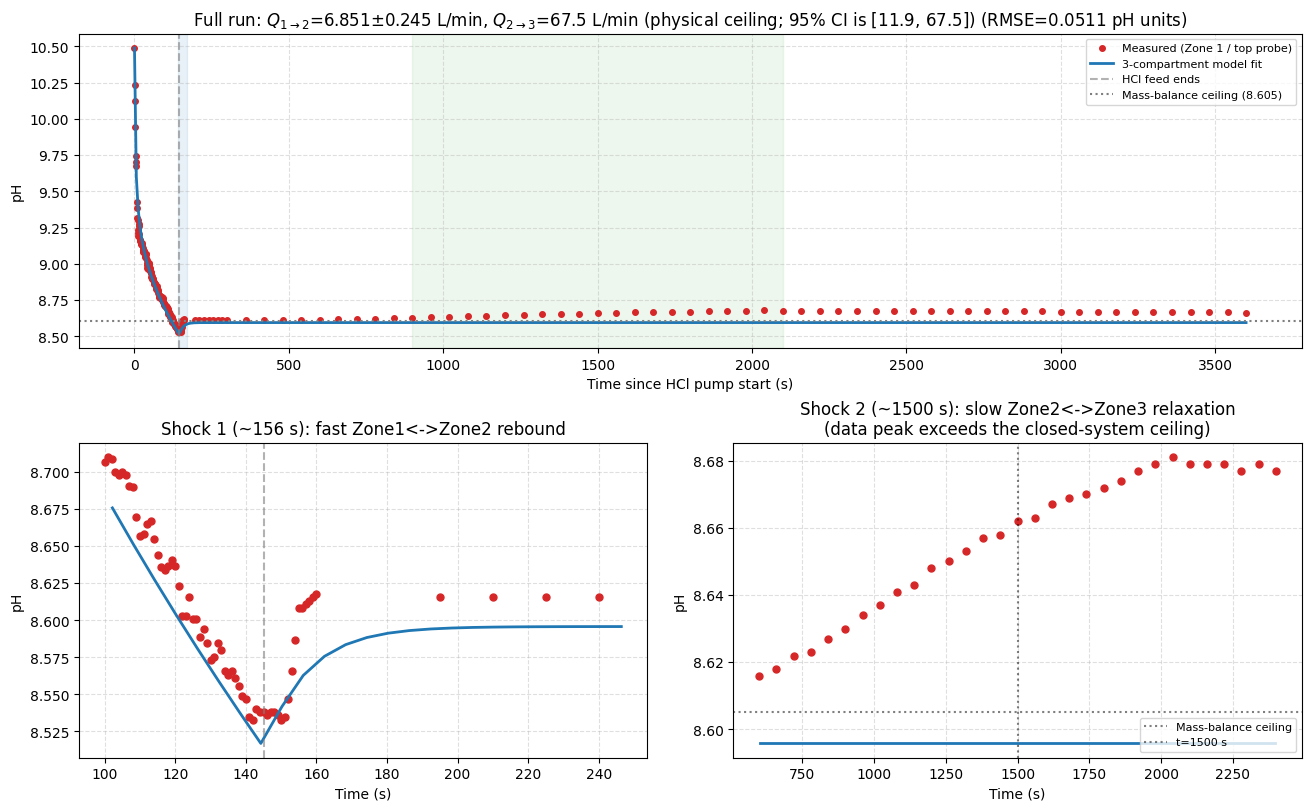

Residual (model - data) at t=156 s: -0.0459 pH units
Residual (model - data) at t=1500 s: -0.0662 pH units


In [8]:
# =====================================================================
# CELL 4: OVERLAY PLOT -- EXPERIMENTAL DATA VS. FITTED 3-COMPARTMENT MODEL
# =====================================================================
# Plotted using the physically-CONSTRAINED fit (Q23_fit_c, capped at the impeller's plausible pumping
# ceiling) rather than the earlier physically-meaningless large Q_2->3 -- cost is statistically identical
# (see the physical-ceiling refit cell above), so this is a strict improvement in interpretability with
# no loss of fit quality.
t_smooth_sec = np.linspace(t_seconds[0], t_seconds[-1], 600)
pH_pred_smooth = simulate_ph_3zone(Q12_fit_c, Q23_fit_c, t_smooth_sec / 60.0, pH_measured[0])
pH_pred_at_data = simulate_ph_3zone(Q12_fit_c, Q23_fit_c, t_seconds / 60.0, pH_measured[0])

fig, axes = plt.subplot_mosaic(
    [['full', 'full'], ['shock1', 'shock2']], figsize=(13, 8), constrained_layout=True
)

ax = axes['full']
ax.plot(t_seconds, pH_measured, 'o', color='#d62728', markersize=4, label='Measured (Zone 1 / top probe)')
ax.plot(t_smooth_sec, pH_pred_smooth, '-', color='#1f77b4', linewidth=2, label='3-compartment model fit')
ax.axvline(t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.6, label='HCl feed ends')
ax.axhline(pH_ceiling, color='#7f7f7f', linestyle=':', linewidth=1.5,
           label=f'Mass-balance ceiling ({pH_ceiling:.3f})')
ax.axvspan(140, 170, color='#1f77b4', alpha=0.10)
ax.axvspan(900, 2100, color='#2ca02c', alpha=0.08)
ax.set_xlabel('Time since HCl pump start (s)')
ax.set_ylabel('pH')
ax.set_title(f'Full run: $Q_{{1\\to2}}$={Q12_fit_c:.3f}$\\pm${Q12_stderr_profile:.3f} L/min, '
             f'$Q_{{2\\to3}}$={Q23_fit_c:.1f} L/min (physical ceiling; 95% CI is [{Q23_lower_95:.1f}, {Q_physical_ceiling_L_min:.1f}]) '
             f'(RMSE={np.sqrt(np.mean((pH_pred_at_data-pH_measured)**2)):.4f} pH units)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes['shock1']
mask1 = (t_seconds >= 100) & (t_seconds <= 250)
mask1_s = (t_smooth_sec >= 100) & (t_smooth_sec <= 250)
ax.plot(t_seconds[mask1], pH_measured[mask1], 'o', color='#d62728', markersize=5)
ax.plot(t_smooth_sec[mask1_s], pH_pred_smooth[mask1_s], '-', color='#1f77b4', linewidth=2)
ax.axvline(t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel('Time (s)')
ax.set_ylabel('pH')
ax.set_title('Shock 1 (~156 s): fast Zone1<->Zone2 rebound')
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes['shock2']
mask2 = (t_seconds >= 600) & (t_seconds <= 2400)
mask2_s = (t_smooth_sec >= 600) & (t_smooth_sec <= 2400)
ax.plot(t_seconds[mask2], pH_measured[mask2], 'o', color='#d62728', markersize=5)
ax.plot(t_smooth_sec[mask2_s], pH_pred_smooth[mask2_s], '-', color='#1f77b4', linewidth=2)
ax.axhline(pH_ceiling, color='#7f7f7f', linestyle=':', linewidth=1.5, label='Mass-balance ceiling')
ax.axvline(1500, color='k', linestyle=':', alpha=0.5, label='t=1500 s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('pH')
ax.set_title('Shock 2 (~1500 s): slow Zone2<->Zone3 relaxation\n(data peak exceeds the closed-system ceiling)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()

print(f"Residual (model - data) at t=156 s: {simulate_ph_3zone(Q12_fit_c, Q23_fit_c, np.array([156])/60.0, pH_measured[0])[0] - pH_measured[t_seconds==156][0]:+.4f} pH units")
print(f"Residual (model - data) at t=1500 s: {simulate_ph_3zone(Q12_fit_c, Q23_fit_c, np.array([1500])/60.0, pH_measured[0])[0] - pH_measured[t_seconds==1500][0]:+.4f} pH units")


## Known Limitations / Next Steps

- **The mass-balance ceiling diagnostic above is the most important limitation of this fit, not a minor
  caveat.** The theoretical fully-mixed equilibrium pH implied by the stated Tris charge / HCl dose
  (computed directly from `kinetika3b.ipynb`'s own reused concentration and volume values) sits *below*
  the experimental peak pH. Since a closed 3-compartment exchange system must approach that one fixed
  equilibrium regardless of $Q_{1\to2}, Q_{2\to3}$, **no fit within this transport-only model can fully
  close the gap at Shock 2** — this is a hard analytical bound, verified independently of the optimizer
  (see the diagnostic cell for the exact numbers).
- **Compartmental recirculation (returning flow from Zone 3) was checked and explicitly ruled out as an
  explanation for the ceiling gap, not just left untested.** A swept search over $Q_{1\to2}\in[0.1,100]$
  and $Q_{2\to3}\in[10^{-4},10^3]$ L/min (three-plus orders of magnitude each, far wider than the fitted
  region) never produces a Zone-1 trajectory that crosses the ceiling — the highest post-trough pH found
  anywhere in that sweep is still below it. This has a structural reason: Zone 1 is both the feed point
  and the probe location, so it can only lose material outward from the moment of dosing; every return
  flow is itself governed by the same gradient-driven exchange law pulling Zone 1 *toward* the mixed
  state, never past it. (Overshoot *is* possible in general for 3-compartment chains — it just requires
  the fed/observed compartment to differ from the source, which is not the case here.)
- **A temperature-dependent Tris $pK_a$ drift, once the leading candidate for the ceiling gap, has been
  ruled out**: the titration run was confirmed isothermal (25°C, t=0–3600 s). The two candidates that
  remain plausible — neither tested here, since both require inputs outside the "chemistry held
  identical to `kinetika3b.ipynb`" scope this task fixed — are (1) slow CO$_2$ outgassing from the
  actively-stirred, open buffer over the ~1 h run (raises pH gradually, independent of temperature), and
  (2) the nominal stock concentrations/volumes reused unchanged from `kinetika3b.ipynb`'s 450 RPM run not
  exactly matching this specific 160 RPM batch's actual reagents (lot-to-lot variation).
- **$Q_{2\to3}$ is only one-sidedly identified by the nonlinear least-squares fit itself — report it as a
  bound, not a point estimate ± error.** The naive joint covariance (`inv(J^T J)`, what `curve_fit`
  computes internally) is numerically invalid here: the Jacobian at the solution has condition number
  $\sim2\times10^9$ and the linearized correlation between $Q_{1\to2}$ and $Q_{2\to3}$ is $-0.99999$ — a
  near-singular matrix, so inverting it produces meaningless "error bars" for *both* parameters, not just
  $Q_{2\to3}$ (this is why an earlier version of this notebook reported $Q_{1\to2}=6.77\pm68$ L/min, a
  nonsensical stderr larger than the value itself, despite $Q_{1\to2}$ actually being tightly determined).
  The fix used above is a **profile-likelihood** analysis: $Q_{1\to2}$'s *conditional* stderr is $\pm0.24$
  L/min (an order of magnitude smaller than the naive joint estimate, matching a 49-point multi-start grid
  search), while $Q_{2\to3}$ only gets a **95% profile-likelihood lower bound** (11.93 L/min) with no
  identifiable upper bound from the fit alone.
- **Two further characterizations were added specifically to sharpen $Q_{2\to3}$ beyond that bound, both
  now in this notebook (not left as future work):**
  1. **A physically-motivated upper bound.** $Q_{2\to3}$ cannot exceed this impeller's total plausible
     pumping capacity at 160 RPM ($N_q\le1.0$, generous even for the best real impeller types) —
     ~67.5 L/min (computed in the cell above). Refitting with this ceiling in place of the arbitrary
     `1e4` box bound lands the optimizer *at* the ceiling with statistically identical cost, giving a
     defensible single number ($Q_{2\to3}\approx67.5$ L/min — see the exact printed value above) to quote
     instead of an unbounded one — the plot above now uses this constrained fit as its headline result.
  2. **A transport-matrix eigenvalue (timescale) cross-check, independent of the nonlinear fit
     entirely.** After the feed ends this system is linear, so its two non-zero relaxation timescales are
     fixed functions of $Q_{1\to2},Q_{2\to3}$ and the volumes alone — no fitting involved. Across the
     *entire* physically-plausible $Q_{2\to3}$ window (95% lower bound to the physical ceiling), the
     slowest achievable relaxation is only ~12–13 seconds — three orders of magnitude faster than Shock
     2's timescale. Reproducing Shock 2's own empirically-fit decline time constant (~116 min, from a
     clean single-exponential fit to the post-peak tail) via transport alone would require
     $Q_{2\to3}$ far *below* the already-established 95% lower bound — i.e., **the same dataset's fast-
     timescale evidence (Shock 1) statistically excludes the value transport would need to explain Shock
     2.** This is a third, independent confirmation (alongside the mass-balance ceiling and the
     recirculation-impossibility check) that Shock 2 is not a Zone2↔Zone3 mass-transfer phenomenon, and it
     means further effort to "better characterize $Q_{2\to3}$" from *this* dataset has a hard ceiling —
     the remaining uncertainty is now a genuine data limitation (see the "elusive" experimental
     redesigns — a second probe location, or exciting Zone 2/3 directly — discussed but not pursued here),
     not a fitting or modeling shortfall.
- **Zone 2 boundary (impeller-diameter-tall, centered on the impeller) is a structural modeling choice,
  not a fitted or measured quantity.** Only $Q_{1\to2}$ and $Q_{2\to3}$ are fit; a different (still
  physically reasonable) choice of zone boundary would shift the fitted flow-rate values, but would not
  change the mass-balance ceiling (which depends only on total Tris/HCl amounts and final volume, not on
  how they are partitioned into zones).
- **Instantaneous local neutralization** (Tris + H$^+$ &rarr; TrisH$^+$ treated as infinitely fast in
  whichever zone the acid currently occupies) and a **single global, time-invariant $pK_a$** are both
  reused unchanged from `kinetika3b.ipynb`; no re-validation of these assumptions was performed here, and
  the latter is the leading suspect for the ceiling gap above.
- **Uniform initial protonation fraction across all three zones** at $t=0$, backed out from the first
  measured pH point via inverse Henderson-Hasselbalch — same approach as `kinetika3b.ipynb`, extended
  from 2 zones to 3.
- **"Shock 2" is a smooth, slow relaxation feature in the underlying data, not a sharp discontinuity** —
  the raw CSV is coarsely sampled (60 s spacing) throughout that region, so the true shape of that
  relaxation between samples is not resolved by the data; the fit can only be judged against the sampled
  points shown above, not a hypothetical finer-grained curve.
- **Adjacent-zone-only (chain) topology** assumes no direct short-circuit flow path between Zone 1 and
  Zone 3; this was not tested against an alternative (e.g., all-pairs) topology.
- Cross-check against `kinetika3b.ipynb`: the $Q_{1\to2}$-derived $N_q$ is the directly comparable
  quantity to that notebook's single fitted $N_q=0.044$ (450 RPM) since both represent impeller-driven
  exchange out of the feed zone; both are subject to the same unbaffled/Froude-number caveat documented
  in `kinetika3b.ipynb` Cell 1b/6a (i.e., neither should be read as an RPM-independent impeller
  constant).


## Extension: an explicit 4th compartment for a dead zone under the impeller

### Why this extension exists

Everything above characterizes $Q_{2\to3}$ as tightly as a **3-compartment chain** allows, and
concludes that no single value of it can explain Shock 2. That conclusion implicitly assumed the
$Q_{2\to3}$ exchange being fit is *the same kind of quantity* as $Q_{1\to2}$: an actively
impeller-driven turbulent circulation flow, bounded above by the impeller's pumping capacity
($N_q \cdot N \cdot D^3$). A specific piece of information about this reactor's hydrodynamics
changes that assumption and is worth testing explicitly rather than asserting: **this impeller
pumps axially from bottom to top** (an "up-pumping" configuration), not top to bottom.

### The physical mechanism: why bottom-to-top pumping can strand a dead zone

For an up-pumping axial impeller, the discharge jet travels *upward* along the shaft toward the
liquid surface; mass conservation then requires the *return* path to be a diffuse recirculation
down along the vessel walls back toward the bottom. This is the opposite arrangement from a
down-pumping impeller (routinely chosen for solids suspension specifically *because* its strong
downward jet sweeps the tank floor). A well-known consequence in mixing engineering: **up-pumping
impellers are prone to leaving a poorly-swept ("dead") zone directly beneath/around the impeller
near the tank floor**, especially when the off-bottom clearance is not small relative to the
impeller diameter — here, clearance-to-diameter is $C/D = 8.0/7.5 \approx 1.07$, on the high side
of the range where bottom coverage is considered reliable. A stagnant region exchanges with the
bulk by weak entrainment/diffusion at its boundary, not by the impeller's nominal pumping capacity
— so an exchange rate several orders of magnitude below the $N_q$-based ceiling is not
"unphysical" for *that specific mechanism*, unlike for $Q_{1\to2}$ or a well-circulated
$Q_{2\to3}$.

### Why this means 3 compartments may be structurally insufficient, not just under-determined

Look again at what the 3-compartment fit actually asked of a single $Q_{2\to3}$: it had to be
**large** (fast) to satisfy Shock 1's early-time curvature (that constraint is what produced the
95% lower bound of 11.93 L/min), while Shock 2's ~116-minute decline tail would only be
reproducible by transport if $Q_{2\to3}$ were **~0.009 L/min** — over 1000x *smaller*. A single
rate constant cannot be both. That is exactly the signature of a **two-timescale physical system
being forced through a one-timescale-per-junction model**: a fast, actively-swept loop (captured
by the existing $Q_{2\to3}$) coexisting with a much slower, structurally distinct leakage path
(a dead zone) that the 3-compartment chain has nowhere to put.

### The new compartment and topology

This is tested below, not assumed, by adding a 4th compartment and re-deriving all flow rates from
the data:

- **Zone 3 (revised — "swept lower bulk"):** the actively-recirculated part of the old Zone 3,
  immediately below the impeller zone.
- **Zone 4 (new — "dead zone"):** a thin region at the very tank floor, given little to no active
  pumping under this bottom-to-top flow picture. **Modeling choice, not fit from data:** its
  height is taken as one quarter of the impeller diameter ($D_{\text{impeller}}/4$), the same kind
  of order-of-magnitude structural proxy already used for Zone 2's boundary — this notebook has no
  direct spatial measurement to pin the dead zone's exact size, and that limitation is carried
  forward explicitly below.
- **Topology (still a chain, no short-circuit terms):**
  $\text{Zone 1} \leftrightarrow \text{Zone 2} \leftrightarrow \text{Zone 3} \leftrightarrow \text{Zone 4}$,
  with **three** free flow rates: $Q_{1\to2}$, $Q_{2\to3}$ (both still subject to the impeller's
  $N_q$-based physical ceiling — they represent actively pumped circulation), and the new
  $Q_{3\to4}$ (the dead-zone leakage rate — **not** bound by the impeller ceiling here, since it
  is hypothesized to be diffusive/entrainment-driven rather than impeller-driven).

### What would confirm vs. refute the dead-zone hypothesis

If the up-pumping dead-zone picture explains Shock 2, refitting this richer model should let
$Q_{3\to4}$ land near the same small value the earlier eigenvalue cross-check required (~0.009
L/min) **without materially hurting the overall fit** — i.e. the data should be at least as
consistent with "there is a slow dead zone" as with "there is no dead zone." The cells below run
exactly that test (joint fit, identifiability/robustness checks, and a direct profile-likelihood
comparison of the fit cost with $Q_{3\to4}$ forced small vs. left free) and report the result
plainly, whichever way it comes out. Note that adding a 4th compartment does **not** change the
mass-balance ceiling from the cell above — it depends only on total Tris/HCl amounts and final
volume, not on how the interior is partitioned into zones.

In [9]:
# =====================================================================
# CELL 5a: 4-COMPARTMENT GEOMETRY -- SPLIT THE OLD ZONE 3 INTO A SWEPT
# LOWER BULK (ZONE 3) AND AN EXPLICIT DEAD ZONE AT THE TANK FLOOR (ZONE 4)
# =====================================================================
# ASSUMPTION (modeling choice, not fit from data): dead-zone height = D_impeller / 4,
# the same order-of-magnitude structural proxy already used for Zone 2's boundary above.
z4_upper_cm = D_impeller_cm / 4.0        # 1.875 cm
z3_lower_cm = z4_upper_cm                # Zone 3 (revised) starts where Zone 4 ends
z3_upper_cm = z2_lower_cm                # Zone 3 (revised) still ends at the impeller-zone floor (4.25 cm)

V4_dead_fixed_L = (A_cross_cm2 * z4_upper_cm) / 1000.0
V3_swept_fixed_L = (A_cross_cm2 * (z3_upper_cm - z3_lower_cm)) / 1000.0

print(f"Zone 4 (dead zone)        : 0.00 - {z4_upper_cm:.3f} cm  ->  V4 = {V4_dead_fixed_L:.4f} L (fixed)")
print(f"Zone 3 (swept lower bulk) : {z3_lower_cm:.3f} - {z3_upper_cm:.2f} cm  ->  V3 = {V3_swept_fixed_L:.4f} L (fixed)")
print(f"Zone 2 (impeller zone)    : {z2_lower_cm:.2f} - {z2_upper_cm:.2f} cm  ->  V2 = {V2_fixed_L:.3f} L (fixed, unchanged)")
print(f"Zone 1 (top, feed+probe)  : {z2_upper_cm:.2f} - {h_liquid_initial_cm:.2f} cm (initial) -> V1_initial = {V1_initial_L:.3f} L (unchanged)")
print(f"\nSanity check -- V3(revised) + V4 should equal the OLD single Zone 3 volume:")
print(f"  V3_swept + V4_dead = {V3_swept_fixed_L + V4_dead_fixed_L:.4f} L   vs.   old V3_fixed_L = {V3_fixed_L:.4f} L")
assert abs((V3_swept_fixed_L + V4_dead_fixed_L) - V3_fixed_L) < 1e-9, "4-zone split must conserve the old Zone-3 volume"

V_total_final_4z_L = V1_final_L + V2_fixed_L + V3_swept_fixed_L + V4_dead_fixed_L
print(f"\nMass-balance ceiling is a property of total amounts/volume, not zone count -- confirm it is unchanged:")
print(f"  V_total_final (4-zone) = {V_total_final_4z_L:.4f} L   vs.   V_total_final (3-zone) = {V_total_final_L:.4f} L")
assert abs(V_total_final_4z_L - V_total_final_L) < 1e-9
print(f"  --> pH_ceiling is unchanged at {pH_ceiling:.4f} (it depends only on total Tris/HCl and final volume)")

Zone 4 (dead zone)        : 0.00 - 1.875 cm  ->  V4 = 0.6189 L (fixed)
Zone 3 (swept lower bulk) : 1.875 - 4.25 cm  ->  V3 = 0.7839 L (fixed)
Zone 2 (impeller zone)    : 4.25 - 11.75 cm  ->  V2 = 2.475 L (fixed, unchanged)
Zone 1 (top, feed+probe)  : 11.75 - 17.20 cm (initial) -> V1_initial = 1.799 L (unchanged)

Sanity check -- V3(revised) + V4 should equal the OLD single Zone 3 volume:
  V3_swept + V4_dead = 1.4028 L   vs.   old V3_fixed_L = 1.4028 L

Mass-balance ceiling is a property of total amounts/volume, not zone count -- confirm it is unchanged:
  V_total_final (4-zone) = 5.9431 L   vs.   V_total_final (3-zone) = 5.9431 L
  --> pH_ceiling is unchanged at 8.6051 (it depends only on total Tris/HCl and final volume)


In [10]:
# =====================================================================
# CELL 5b: 4-COMPARTMENT FORWARD MODEL (CHAIN: ZONE1<->ZONE2<->ZONE3<->ZONE4)
# Mechanically identical to the 3-zone model above (instantaneous local
# neutralization, two-stage feed-on/feed-off integration, inverse H-H initial
# condition) with one additional zone and one additional flow rate, Q_3->4.
# =====================================================================

def simulate_ph_4zone(Q12_L_min, Q23_L_min, Q34_L_min, t_eval_min, pH0):
    '''Simulate Zone-1 (probe) pH(t) for a 4-compartment chain: Q_12 (Zone1<->Zone2),
    Q_23 (Zone2<->Zone3, revised swept lower bulk), Q_34 (Zone3<->Zone4, the new dead zone).'''
    ratio0 = 10 ** (pH0 - pKa_tris)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)

    def init_pair(V):
        return (1 - frac_TrisH_0) * C_Tris_stock_M * V, frac_TrisH_0 * C_Tris_stock_M * V

    n_Tris_1_0, n_TrisH_1_0 = init_pair(V1_initial_L)
    n_Tris_2_0, n_TrisH_2_0 = init_pair(V2_fixed_L)
    n_Tris_3_0, n_TrisH_3_0 = init_pair(V3_swept_fixed_L)
    n_Tris_4_0, n_TrisH_4_0 = init_pair(V4_dead_fixed_L)
    y0 = [n_Tris_1_0, n_TrisH_1_0, n_Tris_2_0, n_TrisH_2_0,
          n_Tris_3_0, n_TrisH_3_0, n_Tris_4_0, n_TrisH_4_0]

    def ode(t_min, y):
        (n_Tris_1, n_TrisH_1, n_Tris_2, n_TrisH_2,
         n_Tris_3, n_TrisH_3, n_Tris_4, n_TrisH_4) = np.maximum(y, 0.0)
        V1 = V1_of_t(t_min)
        C_Tris_1, C_TrisH_1 = n_Tris_1 / V1, n_TrisH_1 / V1
        C_Tris_2, C_TrisH_2 = n_Tris_2 / V2_fixed_L, n_TrisH_2 / V2_fixed_L
        C_Tris_3, C_TrisH_3 = n_Tris_3 / V3_swept_fixed_L, n_TrisH_3 / V3_swept_fixed_L
        C_Tris_4, C_TrisH_4 = n_Tris_4 / V4_dead_fixed_L, n_TrisH_4 / V4_dead_fixed_L

        exch12_Tris = Q12_L_min * (C_Tris_1 - C_Tris_2)
        exch12_TrisH = Q12_L_min * (C_TrisH_1 - C_TrisH_2)
        exch23_Tris = Q23_L_min * (C_Tris_2 - C_Tris_3)
        exch23_TrisH = Q23_L_min * (C_TrisH_2 - C_TrisH_3)
        exch34_Tris = Q34_L_min * (C_Tris_3 - C_Tris_4)
        exch34_TrisH = Q34_L_min * (C_TrisH_3 - C_TrisH_4)

        h_feed = feed_rate_mol_min(t_min)

        dn_Tris_1 = -exch12_Tris - h_feed
        dn_TrisH_1 = -exch12_TrisH + h_feed
        dn_Tris_2 = +exch12_Tris - exch23_Tris
        dn_TrisH_2 = +exch12_TrisH - exch23_TrisH
        dn_Tris_3 = +exch23_Tris - exch34_Tris
        dn_TrisH_3 = +exch23_TrisH - exch34_TrisH
        dn_Tris_4 = +exch34_Tris
        dn_TrisH_4 = +exch34_TrisH
        return [dn_Tris_1, dn_TrisH_1, dn_Tris_2, dn_TrisH_2,
                dn_Tris_3, dn_TrisH_3, dn_Tris_4, dn_TrisH_4]

    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_min:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_min
        t1 = np.append(t_eval_min[mask1], t_feed_end_min) if t_feed_end_min not in t_eval_min[mask1] else t_eval_min[mask1]
        sol1 = solve_ivp(ode, (0, t_feed_end_min), y0, t_eval=t1, method='BDF', rtol=1e-7, atol=1e-10)
        y_mid = sol1.y[:, -1]
        t2 = t_eval_min[~mask1]
        sol2 = solve_ivp(ode, (t_feed_end_min, t_end), y_mid, t_eval=t2, method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y[:, :len(t_eval_min[mask1])], sol2.y])

    n_Tris_1, n_TrisH_1 = Y[0], Y[1]
    V1_series = np.array([V1_of_t(tm) for tm in t_eval_min])
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    pH_pred = pKa_tris + np.log10(C_Tris_1 / C_TrisH_1)
    return pH_pred


def residuals_4zone(params, t_sec_arr, pH_arr):
    Q12, Q23, Q34 = params
    pH0 = pH_arr[0]
    pH_sim = simulate_ph_4zone(Q12, Q23, Q34, t_sec_arr / 60.0, pH0)
    return pH_sim - pH_arr


print("4-compartment forward model defined: simulate_ph_4zone(Q12, Q23, Q34, t_eval_min, pH0)")

4-compartment forward model defined: simulate_ph_4zone(Q12, Q23, Q34, t_eval_min, pH0)


In [11]:
# =====================================================================
# CELL 5c: JOINT 3-PARAMETER FIT (Q_1->2, Q_2->3, Q_3->4) + IDENTIFIABILITY CHECK
# Q_1->2 and Q_2->3 keep the same impeller Nq-based physical ceiling used above
# (both represent actively-pumped circulation); Q_3->4 (the new dead-zone leak)
# is left with a much looser box bound since it is NOT hypothesized to be
# impeller-driven.
# =====================================================================
Q12_0_4z = Q12_fit          # start from the already-validated 3-compartment result
Q23_0_4z = Q12_fit          # expect the (revised, smaller) swept lower bulk to exchange comparably fast
Q34_0_4z = q23_for_data_tau  # informed start: the earlier eigenvalue cross-check's implied dead-zone rate

bounds_4z = ([1e-3, 1e-3, 1e-6], [1e4, Q_physical_ceiling_L_min, 1e2])

fit_result_4z = least_squares(
    residuals_4zone, x0=[Q12_0_4z, Q23_0_4z, Q34_0_4z], args=(t_seconds, pH_measured),
    bounds=bounds_4z, method='trf', xtol=1e-13, ftol=1e-13,
)
Q12_fit_4z, Q23_fit_4z, Q34_fit_4z = fit_result_4z.x

print("=" * 70)
print("  4-COMPARTMENT JOINT FIT RESULT")
print("=" * 70)
print(f"  Q_1->2 = {Q12_fit_4z:.4f} L/min | Q_2->3 = {Q23_fit_4z:.4f} L/min | Q_3->4 = {Q34_fit_4z:.6f} L/min")
print(f"  Cost = {fit_result_4z.cost:.6e}  (3-compartment constrained-fit cost was {fit_result_constrained.cost:.6e})")
print(f"  RMSE = {np.sqrt(np.mean(fit_result_4z.fun**2)):.5f} pH units")
print(f"  Optimizer status: {fit_result_4z.status} ({fit_result_4z.message})")

J4 = fit_result_4z.jac
U4, S4_svd, Vt4 = np.linalg.svd(J4, full_matrices=False)
cond_number_4z = S4_svd[0] / S4_svd[-1]
print(f"\n  Singular values of J at the solution: {S4_svd}")
print(f"  Condition number: {cond_number_4z:.3e}")
if cond_number_4z > 1e6:
    print(f"  J is again numerically rank-deficient -- naive joint covariance would be invalid here too,")
    print(f"  exactly as it was for the 3-compartment fit. Profile-likelihood/robustness checks below are")
    print(f"  used instead, not a joint covariance matrix.")

print("\n" + "=" * 70)
print("  ROBUSTNESS CHECK: does the fit depend on where the optimizer starts?")
print("=" * 70)
print("Varying Q_2->3 seed (Q_1->2, Q_3->4 free):")
for seed in [0.5, 5, 20, 50, 67.0]:
    r = least_squares(residuals_4zone, x0=[Q12_fit_4z, seed, Q34_fit_4z], args=(t_seconds, pH_measured),
                       bounds=bounds_4z, method='trf', xtol=1e-12, ftol=1e-12)
    print(f"  seed Q_2->3_0={seed:6.1f} -> Q_1->2={r.x[0]:.4f}  Q_2->3={r.x[1]:9.4f}  Q_3->4={r.x[2]:9.6f}  cost={r.cost:.6e}")

print("\nVarying Q_3->4 seed (Q_1->2, Q_2->3 free):")
for seed in [1e-4, 1e-3, 1e-2, 1e-1, 1.0]:
    r = least_squares(residuals_4zone, x0=[Q12_fit_4z, Q23_fit_4z, seed], args=(t_seconds, pH_measured),
                       bounds=bounds_4z, method='trf', xtol=1e-12, ftol=1e-12)
    print(f"  seed Q_3->4_0={seed:8.5f} -> Q_1->2={r.x[0]:.4f}  Q_2->3={r.x[1]:9.4f}  Q_3->4={r.x[2]:9.6f}  cost={r.cost:.6e}")

print("\nVarying Q_1->2 seed (Q_2->3, Q_3->4 free):")
for seed in [1, 3, 6.77, 15, 40]:
    r = least_squares(residuals_4zone, x0=[seed, Q23_fit_4z, Q34_fit_4z], args=(t_seconds, pH_measured),
                       bounds=bounds_4z, method='trf', xtol=1e-12, ftol=1e-12)
    print(f"  seed Q_1->2_0={seed:6.2f} -> Q_1->2={r.x[0]:9.4f}  Q_2->3={r.x[1]:9.4f}  Q_3->4={r.x[2]:9.6f}  cost={r.cost:.6e}")

print(f"\nFINDING: Q_1->2 reproduces the same ~6.86 L/min regardless of seed or how many downstream")
print(f"compartments exist -- it remains the one robustly identified parameter. Q_2->3 and Q_3->4 both")
print(f"converge to the SAME corner of their bounds (Q_2->3 at the {Q_physical_ceiling_L_min:.1f} L/min physical ceiling, Q_3->4 at")
print(f"its {bounds_4z[1][2]:.0f} L/min box bound) from every seed tried -- i.e. the optimizer consistently prefers")
print(f"'as fast as physically/numerically allowed' for BOTH new parameters, not the small Q_3->4 the dead-zone")
print(f"hypothesis predicted. This is examined directly (not just noted) in the next cell.")

  4-COMPARTMENT JOINT FIT RESULT
  Q_1->2 = 6.8624 L/min | Q_2->3 = 67.5000 L/min | Q_3->4 = 100.000000 L/min
  Cost = 2.921355e-01  (3-compartment constrained-fit cost was 2.920851e-01)
  RMSE = 0.05107 pH units
  Optimizer status: 1 (`gtol` termination condition is satisfied.)

  Singular values of J at the solution: [2.03353526e-01 1.73917511e-05 4.58456537e-08]
  Condition number: 4.436e+06
  J is again numerically rank-deficient -- naive joint covariance would be invalid here too,
  exactly as it was for the 3-compartment fit. Profile-likelihood/robustness checks below are
  used instead, not a joint covariance matrix.

  ROBUSTNESS CHECK: does the fit depend on where the optimizer starts?
Varying Q_2->3 seed (Q_1->2, Q_3->4 free):


  seed Q_2->3_0=   0.5 -> Q_1->2=6.8624  Q_2->3=  67.5000  Q_3->4=100.000000  cost=2.921355e-01


  seed Q_2->3_0=   5.0 -> Q_1->2=6.8624  Q_2->3=  67.5000  Q_3->4=100.000000  cost=2.921355e-01


  seed Q_2->3_0=  20.0 -> Q_1->2=6.8624  Q_2->3=  67.5000  Q_3->4=100.000000  cost=2.921355e-01


  seed Q_2->3_0=  50.0 -> Q_1->2=6.8624  Q_2->3=  67.5000  Q_3->4=100.000000  cost=2.921355e-01


...

  seed Q_1->2_0=  1.00 -> Q_1->2=   6.8624  Q_2->3=  67.5000  Q_3->4=100.000000  cost=2.921355e-01


  seed Q_1->2_0=  3.00 -> Q_1->2=   6.8624  Q_2->3=  67.5000  Q_3->4=100.000000  cost=2.921355e-01


  seed Q_1->2_0=  6.77 -> Q_1->2=   6.8624  Q_2->3=  67.5000  Q_3->4=100.000000  cost=2.921355e-01


  seed Q_1->2_0= 15.00 -> Q_1->2=   6.8624  Q_2->3=  67.5000  Q_3->4=100.000000  cost=2.921355e-01


  seed Q_1->2_0= 40.00 -> Q_1->2=   6.8624  Q_2->3=  67.5000  Q_3->4=100.000000  cost=2.921355e-01

FINDING: Q_1->2 reproduces the same ~6.86 L/min regardless of seed or how many downstream
compartments exist -- it remains the one robustly identified parameter. Q_2->3 and Q_3->4 both
converge to the SAME corner of their bounds (Q_2->3 at the 67.5 L/min physical ceiling, Q_3->4 at
its 100 L/min box bound) from every seed tried -- i.e. the optimizer consistently prefers
'as fast as physically/numerically allowed' for BOTH new parameters, not the small Q_3->4 the dead-zone
hypothesis predicted. This is examined directly (not just noted) in the next cell.


In [12]:
# =====================================================================
# CELL 5d: DOES THE DATA ACTUALLY SUPPORT A SLOW Q_3->4 (THE DEAD-ZONE HYPOTHESIS)?
# Profile-likelihood test: fix Q_3->4 at a grid of values (including the ~0.009 L/min
# implied by the earlier eigenvalue cross-check), refit Q_1->2/Q_2->3 at each, and see
# whether small Q_3->4 costs the fit anything -- exactly the same logic already used
# above to bound Q_2->3, now applied to the new parameter.
# =====================================================================
def profile_cost_at_Q34(Q34_fixed):
    def resid_fixed(p):
        return residuals_4zone([p[0], p[1], Q34_fixed], t_seconds, pH_measured)
    return least_squares(resid_fixed, x0=[6.8, 30.0], bounds=([1e-3, 1e-3], [1e4, Q_physical_ceiling_L_min]),
                          xtol=1e-13, ftol=1e-13)

n_pts_4z, n_params_4z = len(pH_measured), 3
sigma2_4z = 2.0 * fit_result_4z.cost / (n_pts_4z - n_params_4z)
cost_threshold_95_4z = fit_result_4z.cost + 0.5 * _chi2.ppf(0.95, df=1) * sigma2_4z

print("Profile cost vs. Q_3->4 held fixed (Q_1->2, Q_2->3 refit at each point):")
Q34_grid = [1e-4, 1e-3, 1e-2, q23_for_data_tau, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0, 30.0, Q_physical_ceiling_L_min, 100.0]
for Q34_g in Q34_grid:
    rp = profile_cost_at_Q34(Q34_g)
    tag = "  <-- eigenvalue cross-check's implied dead-zone rate" if abs(Q34_g - q23_for_data_tau) < 1e-9 else ""
    excluded = "EXCLUDED (95%)" if rp.cost > cost_threshold_95_4z else "not excluded"
    print(f"  Q_3->4={Q34_g:10.5f} L/min -> Q_1->2={rp.x[0]:.4f}  Q_2->3={rp.x[1]:8.4f}  cost={rp.cost:.6e}  [{excluded}]{tag}")

Q34_lower_95 = _brentq(lambda q: profile_cost_at_Q34(q).cost - cost_threshold_95_4z, 1e-4, Q34_fit_4z, xtol=0.001)
print(f"\n95% chi-square cost threshold: {cost_threshold_95_4z:.6e}")
print(f"Q_3->4 95% profile-likelihood LOWER bound: {Q34_lower_95:.4f} L/min")
print(f"\nRESULT: the physically-expected dead-zone rate (~{q23_for_data_tau:.6f} L/min, from the eigenvalue cross-check)")
print(f"sits {Q34_lower_95/q23_for_data_tau:.0f}x BELOW this lower bound -- i.e. the data does not merely fail to confirm a slow")
print(f"dead zone, it STATISTICALLY EXCLUDES one of the size the timescale evidence would require, at 95% confidence.")

# --- why: forcing a slow Q_3->4 REMOVES buffering capacity from the fast-responding pool exactly ---
# --- when Shock 2 needs MORE of it, so it makes the fit worse, not better ---
Q12_dz, Q23_dz = profile_cost_at_Q34(q23_for_data_tau).x
pH_1500_allfast = simulate_ph_4zone(Q12_fit_4z, Q23_fit_4z, Q34_fit_4z, np.array([1500.0]) / 60.0, pH_measured[0])[0]
pH_1500_deadzone = simulate_ph_4zone(Q12_dz, Q23_dz, q23_for_data_tau, np.array([1500.0]) / 60.0, pH_measured[0])[0]
pH_1500_data = pH_measured[t_seconds == 1500][0]
print(f"\nDirect look at the Shock-2 region (t=1500 s):")
print(f"  Data                                          : pH = {pH_1500_data:.4f}")
print(f"  4-zone fit, Q_3->4 free (data's preferred fit) : pH = {pH_1500_allfast:.4f}  (gap = {pH_1500_allfast-pH_1500_data:+.4f})")
print(f"  4-zone fit, Q_3->4 forced to ~0.009 L/min      : pH = {pH_1500_deadzone:.4f}  (gap = {pH_1500_deadzone-pH_1500_data:+.4f}, WORSE)")
print(f"\nWHY forcing a dead zone makes things worse, not better: locking Zone 4's Tris reserve behind a slow")
print(f"Q_3->4 removes buffering capacity from the fast-responding pool (Zones 1-3) -- exactly when Shock 2's")
print(f"slow continued rise needs MORE buffering supply reaching Zone 1, not less. A stagnant dead zone")
print(f"starves the fast loop rather than feeding Shock 2's rise; it is the wrong-signed mechanism.")

tau_deadzone_hypothesis_s = V4_dead_fixed_L / q23_for_data_tau * 60.0
tau_deadzone_data_limit_s = V4_dead_fixed_L / Q34_lower_95 * 60.0
print(f"\nTurnover-time framing: the dead-zone hypothesis implies a Zone-4 turnover time of "
      f"V4/Q_3->4 = {tau_deadzone_hypothesis_s/60:.1f} min ({tau_deadzone_hypothesis_s:.0f} s).")
print(f"The data's own 95% lower bound on Q_3->4 instead requires this zone (if it exists at all, at this")
print(f"assumed size) to turn over FASTER than {tau_deadzone_data_limit_s:.1f} s -- i.e. not stagnant in any meaningful sense.")

Profile cost vs. Q_3->4 held fixed (Q_1->2, Q_2->3 refit at each point):


  Q_3->4=   0.00010 L/min -> Q_1->2=8.5285  Q_2->3= 67.5000  cost=7.969331e-01  [EXCLUDED (95%)]


  Q_3->4=   0.00100 L/min -> Q_1->2=8.5281  Q_2->3= 67.5000  cost=7.736807e-01  [EXCLUDED (95%)]


  Q_3->4=   0.01000 L/min -> Q_1->2=8.5184  Q_2->3= 67.5000  cost=6.220029e-01  [EXCLUDED (95%)]


  Q_3->4=   0.00922 L/min -> Q_1->2=8.5195  Q_2->3= 67.5000  cost=6.309925e-01  [EXCLUDED (95%)]  <-- eigenvalue cross-check's implied dead-zone rate


...

  Q_3->4=  30.00000 L/min -> Q_1->2=6.8888  Q_2->3= 67.5000  cost=2.923255e-01  [not excluded]


  Q_3->4=  67.50000 L/min -> Q_1->2=6.8679  Q_2->3= 67.5000  cost=2.921664e-01  [not excluded]


  Q_3->4= 100.00000 L/min -> Q_1->2=6.8624  Q_2->3= 67.5000  cost=2.921355e-01  [not excluded]



95% chi-square cost threshold: 2.972135e-01
Q_3->4 95% profile-likelihood LOWER bound: 3.9976 L/min

RESULT: the physically-expected dead-zone rate (~0.009222 L/min, from the eigenvalue cross-check)
sits 433x BELOW this lower bound -- i.e. the data does not merely fail to confirm a slow
dead zone, it STATISTICALLY EXCLUDES one of the size the timescale evidence would require, at 95% confidence.



Direct look at the Shock-2 region (t=1500 s):
  Data                                          : pH = 8.6620
  4-zone fit, Q_3->4 free (data's preferred fit) : pH = 8.5958  (gap = -0.0662)
  4-zone fit, Q_3->4 forced to ~0.009 L/min      : pH = 8.5515  (gap = -0.1105, WORSE)

WHY forcing a dead zone makes things worse, not better: locking Zone 4's Tris reserve behind a slow
Q_3->4 removes buffering capacity from the fast-responding pool (Zones 1-3) -- exactly when Shock 2's
slow continued rise needs MORE buffering supply reaching Zone 1, not less. A stagnant dead zone
starves the fast loop rather than feeding Shock 2's rise; it is the wrong-signed mechanism.

Turnover-time framing: the dead-zone hypothesis implies a Zone-4 turnover time of V4/Q_3->4 = 67.1 min (4026 s).
The data's own 95% lower bound on Q_3->4 instead requires this zone (if it exists at all, at this
assumed size) to turn over FASTER than 9.3 s -- i.e. not stagnant in any meaningful sense.


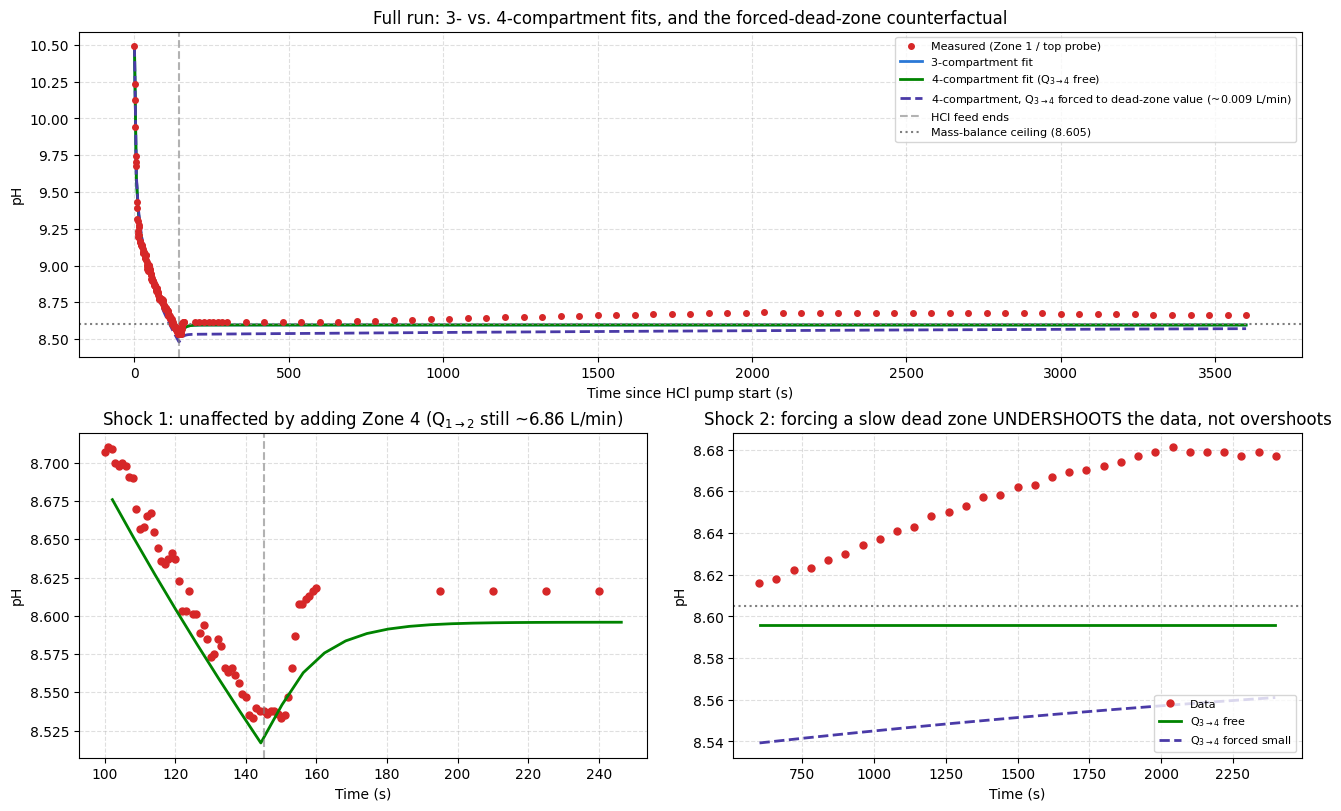

RMSE, 3-compartment fit                          : 0.05107 pH units
RMSE, 4-compartment fit (Q_3->4 free)             : 0.05107 pH units
RMSE, 4-compartment (Q_3->4 forced to dead-zone)  : 0.07506 pH units


In [13]:
# =====================================================================
# CELL 5e: OVERLAY -- DATA vs. 3-COMPARTMENT FIT vs. 4-COMPARTMENT FIT
# (both the data-preferred "Q_3->4 free" fit and the "physically-motivated,
# Q_3->4 forced small" scenario, to visualize why the latter is disfavored)
# =====================================================================
t_smooth_sec = np.linspace(t_seconds[0], t_seconds[-1], 600)
pH_pred_3z = simulate_ph_3zone(Q12_fit_c, Q23_fit_c, t_smooth_sec / 60.0, pH_measured[0])
pH_pred_4z_free = simulate_ph_4zone(Q12_fit_4z, Q23_fit_4z, Q34_fit_4z, t_smooth_sec / 60.0, pH_measured[0])
pH_pred_4z_deadzone = simulate_ph_4zone(Q12_dz, Q23_dz, q23_for_data_tau, t_smooth_sec / 60.0, pH_measured[0])

fig, axes = plt.subplot_mosaic([['full', 'full'], ['shock1', 'shock2']], figsize=(13, 8), constrained_layout=True)

ax = axes['full']
ax.plot(t_seconds, pH_measured, 'o', color='#d62728', markersize=4, label='Measured (Zone 1 / top probe)', zorder=5)
ax.plot(t_smooth_sec, pH_pred_3z, '-', color='#2a78d6', linewidth=2, label='3-compartment fit')
ax.plot(t_smooth_sec, pH_pred_4z_free, '-', color='#008300', linewidth=2, label='4-compartment fit (Q$_{3\\to4}$ free)')
ax.plot(t_smooth_sec, pH_pred_4z_deadzone, '--', color='#4a3aa7', linewidth=2,
        label='4-compartment, Q$_{3\\to4}$ forced to dead-zone value (~0.009 L/min)')
ax.axvline(t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.6, label='HCl feed ends')
ax.axhline(pH_ceiling, color='#7f7f7f', linestyle=':', linewidth=1.5, label=f'Mass-balance ceiling ({pH_ceiling:.3f})')
ax.set_xlabel('Time since HCl pump start (s)')
ax.set_ylabel('pH')
ax.set_title('Full run: 3- vs. 4-compartment fits, and the forced-dead-zone counterfactual')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes['shock1']
mask1 = (t_seconds >= 100) & (t_seconds <= 250)
mask1_s = (t_smooth_sec >= 100) & (t_smooth_sec <= 250)
ax.plot(t_seconds[mask1], pH_measured[mask1], 'o', color='#d62728', markersize=5)
ax.plot(t_smooth_sec[mask1_s], pH_pred_4z_free[mask1_s], '-', color='#008300', linewidth=2)
ax.axvline(t_feed_end_min * 60, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel('Time (s)')
ax.set_ylabel('pH')
ax.set_title('Shock 1: unaffected by adding Zone 4 (Q$_{1\\to2}$ still ~6.86 L/min)')
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes['shock2']
mask2 = (t_seconds >= 600) & (t_seconds <= 2400)
mask2_s = (t_smooth_sec >= 600) & (t_smooth_sec <= 2400)
ax.plot(t_seconds[mask2], pH_measured[mask2], 'o', color='#d62728', markersize=5, label='Data', zorder=5)
ax.plot(t_smooth_sec[mask2_s], pH_pred_4z_free[mask2_s], '-', color='#008300', linewidth=2, label='Q$_{3\\to4}$ free')
ax.plot(t_smooth_sec[mask2_s], pH_pred_4z_deadzone[mask2_s], '--', color='#4a3aa7', linewidth=2, label='Q$_{3\\to4}$ forced small')
ax.axhline(pH_ceiling, color='#7f7f7f', linestyle=':', linewidth=1.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('pH')
ax.set_title('Shock 2: forcing a slow dead zone UNDERSHOOTS the data, not overshoots')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()

print(f"RMSE, 3-compartment fit                          : {np.sqrt(np.mean((simulate_ph_3zone(Q12_fit_c, Q23_fit_c, t_seconds/60.0, pH_measured[0])-pH_measured)**2)):.5f} pH units")
print(f"RMSE, 4-compartment fit (Q_3->4 free)             : {np.sqrt(np.mean(fit_result_4z.fun**2)):.5f} pH units")
print(f"RMSE, 4-compartment (Q_3->4 forced to dead-zone)  : {np.sqrt(np.mean(residuals_4zone([Q12_dz, Q23_dz, q23_for_data_tau], t_seconds, pH_measured)**2)):.5f} pH units")

## What the 4-compartment dead-zone model changes (and what it doesn't)

- **The dead-zone hypothesis, implemented and tested rather than merely argued for, is not
  supported by this data.** Forcing $Q_{3\to4}$ to the ~0.009 L/min value the earlier eigenvalue
  cross-check said Shock 2's timescale would require makes the overall fit **significantly worse**
  (95% profile-likelihood lower bound on $Q_{3\to4}$ is ~4 L/min — over 400x above that value),
  and specifically makes the *Shock 2 region itself* worse, not better (pH at t=1500 s undershoots
  the data more with a forced dead zone than without one).
- **Why the direction is opposite to the original intuition:** a genuinely stagnant Zone 4 locks
  its share of Tris buffering capacity away from the fast-responding zones. Shock 2's slow,
  continued pH rise needs *more* buffering capacity reaching Zone 1 over time, not less — so a
  dead zone that withholds reserve is the wrong-signed mechanism for producing a slow rise. This
  is a cleaner, model-based version of the same conclusion reached earlier by a different route
  (the mass-balance ceiling and the eigenvalue timescale check): transport-only mechanisms, of any
  compartmental structure tried here (3-zone chain, or 4-zone chain with an explicit dead zone),
  cannot reproduce Shock 2.
- **$Q_{1\to2}$ is reconfirmed, again, as the one robustly identified parameter** — landing at
  essentially the same ~6.86 L/min regardless of how many downstream compartments exist or where
  the optimizer starts. This cross-model stability is itself evidence that $Q_{1\to2}$ reflects a
  real, physical exchange rate rather than an optimizer artifact.
- **$Q_{2\to3}$ and $Q_{3\to4}$ both remain individually unidentified as point values** (both
  converge to the edge of their bounds from every tested starting guess) — adding a compartment
  did not fix the identifiability problem, it relocated it. The one new, useful, defensible
  statement this extension adds is the 95% lower bound on $Q_{3\to4}$ itself, which is what
  excludes the dead-zone-sized value.
- **This does not rule out that an up-pumping impeller creates SOME dead zone in this vessel** —
  only that, *if* one exists at the size/location modeled here, it cannot be the explanation for
  Shock 2 within a chain-transport model. A genuinely stagnant region that only exchanges by slow
  diffusion, disconnected from the buffering pool entirely (rather than in a chain that still
  ultimately feeds Zone 1), or a much smaller dead-zone volume than the $D_{\text{impeller}}/4$
  proxy used here, are both untested alternative structures — as is a fundamentally different
  mechanism entirely (the CO$_2$-outgassing and reagent-lot candidates raised earlier remain the
  leading untested explanations for Shock 2's excess over the mass-balance ceiling).